<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/PRACTICA_AST_Clase_7_1_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 7 - AutoML</h3>
    <h3>Ejercicio 1_Sincronico</h3>
        <p>Docente: Sebastian Calcagno, Rodrigo Del Rosso, Drago Braian <p>
</div>

Aca veremos como podemos utilizar herramientas de AutoML en un problema de series temporales. Asi vamos a es predecir el nivel futuro de contaminacion, especificamente PM2.5 usando info historica de contaminacion y variables meteoroloicas. La base corresponde a datos horarios de contaminacion y clima de Beijing durante varios años. Tenemos como variable principal pollution, que representa la concentracion de PM2.5, junto con variables como temperatura, presion, punto de rocio, direccion y velocidad del viento, lluvia y nieve

In [ ]:
!pip uninstall -y scipy

Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3


In [ ]:
!pip install scipy==1.13.0 gensim==4.3.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 12.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done


In [ ]:
!pip install scipy==1.14.0 tsfresh

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 21.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.0
    Uninstalling scipy-1.13.0:
      Successfully uninstalled scipy-1.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.14.0 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [ ]:
#librerias de autoML --  18.55

# Se instalan las librerías
!pip install h2o
!pip install autoviz
!pip install seaborn
!pip install sweetviz
#!pip install tsfresh



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.2
    Uninstalling xgboost-3.1.2:
      Successfully uninstalled xgboost-3.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 79.8 MB/s eta 0:00:00


In [ ]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import h2o
from h2o.automl import H2OAutoML
import gc
from autoviz.AutoViz_Class import AutoViz_Class
import sweetviz
from IPython.display import YouTubeVideo
from tsfresh import extract_features
import statsmodels.api as sm
#from darts import TimeSeries
#from darts.models import (NaiveSeasonal,NaiveDrift,RNNModel,Prophet,ExponentialSmoothing,ARIMA,AutoARIMA,TCNModel,TransformerModel,Theta,FFT)
%matplotlib inline

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


In [ ]:
!pip install ydata-profiling



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.2 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
#automatizaion de los reportes -- yahoodata profiling

No aplica para este ejemplo pero con esta [librería](https://github.com/8080labs/pyforest), se pueden importar muchas librerías en un línea de código

In [ ]:
#!pip install pyforest
#from pyforest import *

En este [link](https://github.com/MaxBenChrist/awesome_time_series_in_python) encontrarán librerías útiles para series de tiempo

# Ejemplo Dataset "Contaminación"

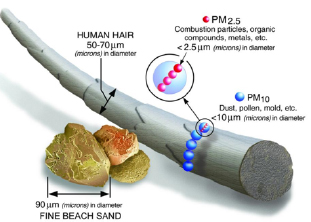

Esta base de datos informa sobre el clima y el nivel de contaminación cada hora durante cinco años en la embajada de Estados Unidos ubicada en Beijing, China.  

El PM2.5 se refiere a la materia particulada atmosférica (PM µg/m3), la cual tiene una diámetro menor a 2.5 micrómetros, equivalente a aproximadamente un 3% del diámetro de un pelo humano.  Las partículas son tan pequeñas que comúnmente solo son medibles a través de microscopios de electrónicos.

Estas partículas finas provienen de diversas fuentes. Desde polvo de plantas, vehículos de motor, aviones, incendios forestales, tormentas de arena, quema agropecuaria y de agricultura, entre otros.

**¿Por qué el PM2.5 es Peligroso?**  
Debido a que son partículas tan ligeras y tan pequeñas, estas tienden a permanecer más tiempo en el aire al compararlas con otras más pesadas.  Lo anterior incrementa la probabilidad de que estas partículas sean inhaladas por personas o animales. Partículas de este tamaño, pueden entrar por la nariz, pasar por la garganta y penetrar de forma profunda en los pulmones; algunas incluso pueden llegar hasta el sistema circulatorio.  

El muestreo de aire es cualquier método para tomar un volumen representativo de aire y analizar su contaminación química, de partículas o radioactiva.  Las muestras se recolectan al vacío en un filtro o resina, se procesan más mediante limpieza del filtro, extracción o incineración, y luego se evalúan utilizando métodos gravimétricos, microscopía o equipo.

**Variables:**
*   date: fecha y hora
*   pollution: concentración de PM2.5 (Contaminación)
*   dew: punto de rocío
*   temp: temperatura
*   press: Presión
*   wnd_dir: dirección del viento
*   wnd_spd: velocidad del viento acumulada
*   snow: horas acumuladas de nieve
*   rain: horas acumuladas de lluvia





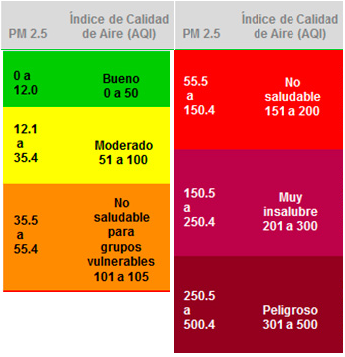

## **Análisis Exploratorio**





In [ ]:
# Se carga la base
url='https://raw.githubusercontent.com/braiandrago/AST/main/pollution.csv'
df = pd.read_csv(url,index_col=0,parse_dates=True)
df.head()

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
date,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0


In [ ]:
# Análisis exploratorio general
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  43800 non-null  float64
 1   dew        43800 non-null  int64  
 2   temp       43800 non-null  float64
 3   press      43800 non-null  float64
 4   wnd_dir    43800 non-null  object 
 5   wnd_spd    43800 non-null  float64
 6   snow       43800 non-null  int64  
 7   rain       43800 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 3.0+ MB


In [ ]:
# Análisis exploratorio por variable
df.describe()

,pollution,dew,temp,press,wnd_spd,snow,rain
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,94.013516,1.828516,12.459041,1016.447306,23.894307,0.052763,0.195023
std,92.252276,14.429326,12.193384,10.271411,50.022729,0.760582,1.416247
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,24.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,68.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,132.250000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


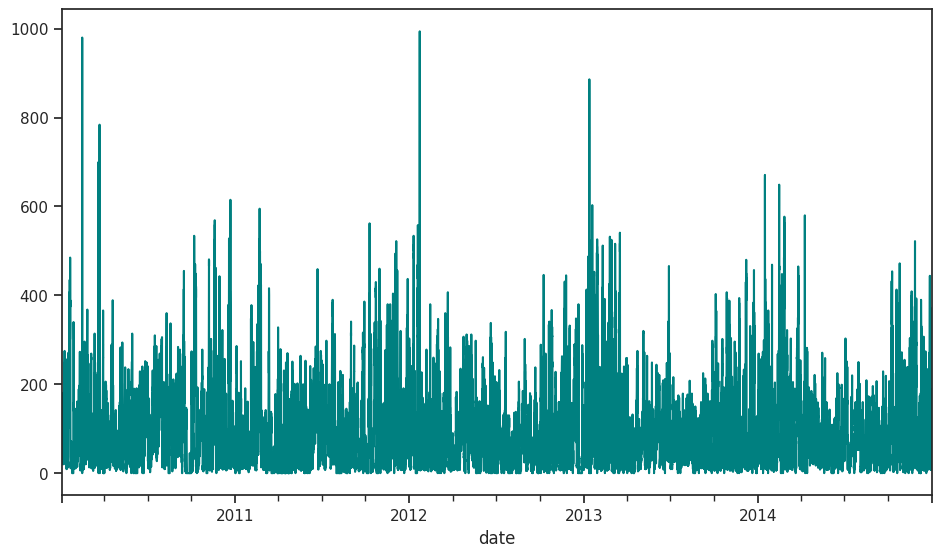

In [ ]:
# Se grafica la contaminación
ax= df['pollution'].plot(label='Contaminación', color='teal', figsize=(10, 6));

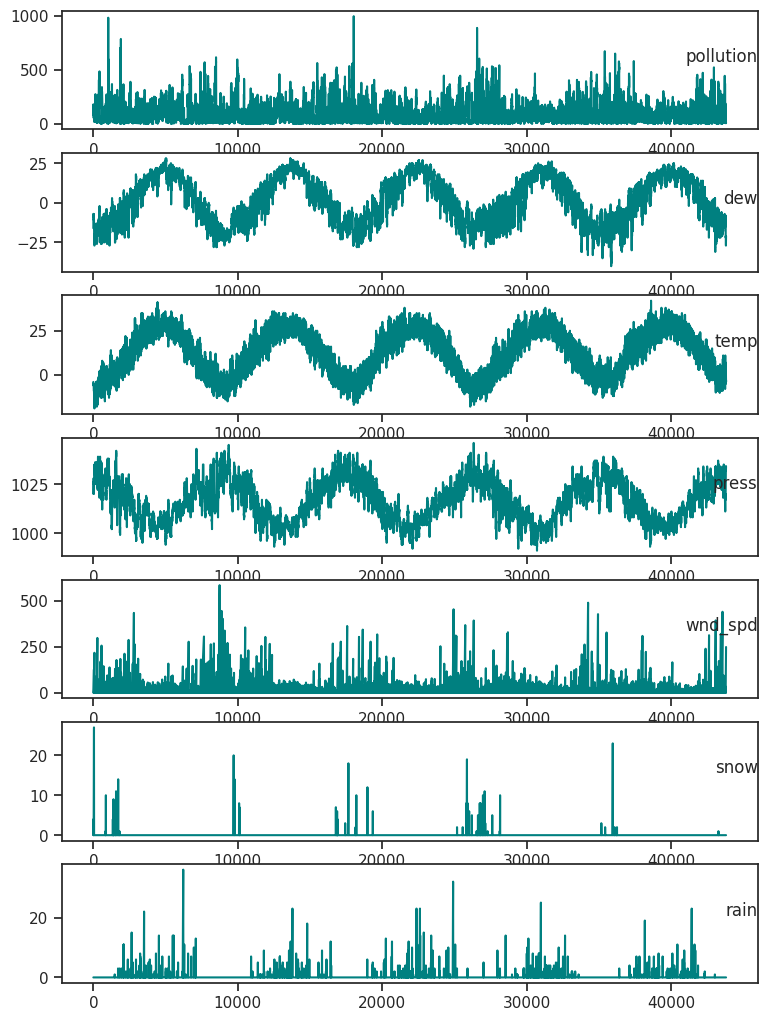

In [ ]:
# Se grafica la evolución de todas las variables
plt.figure(figsize=(8, 12))
values = df.values
groups = [0, 1, 2, 3, 5, 6, 7]
i = 1
# plot each column
#plt.figure()
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(values[:, group],color='teal')
    plt.title(df.columns[group], y=0.5, loc='right')
    i += 1
plt.show()

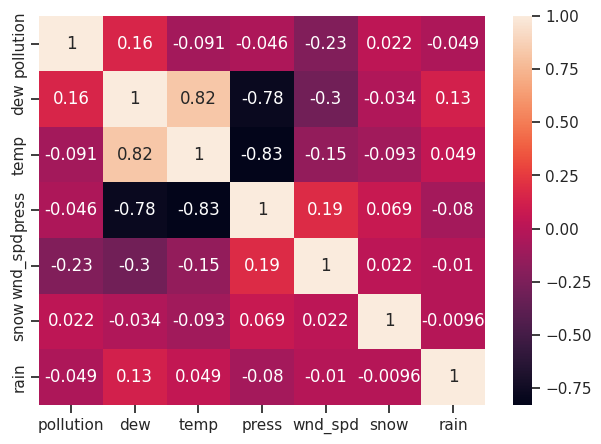

<Figure size 640x480 with 0 Axes>

In [ ]:
# Matriz de correlación
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corrMatrix =numeric_df.corr()
sn.heatmap(corrMatrix, annot = True, )
plt.figure()
plt.show()

## Análisis exploratorio automático

Shape of your Data Set loaded: (43800, 9)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  3
    Number of Integer-Categorical Columns =  3
    Number of String-Categorical Columns =  1
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  1
    Number of Columns to Delete =  0
    8 Predictors classified...
        1 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['date']

################ Regression problem #####################
T

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
dew,int64,0.000000,0,-40.000000,28.000000,Column has a high correlation with ['temp']. Consider dropping one of them.
temp,float64,0.000000,NA,-19.000000,42.000000,No issue
press,float64,0.000000,NA,991.000000,1046.000000,Column has a high correlation with ['temp']. Consider dropping one of them.
wnd_dir,object,0.000000,0,,,No issue
wnd_spd,float64,0.000000,NA,0.450000,585.600000,Column has 5101 outliers greater than upper bound (52.09) or lower than lower bound(-28.39). Cap them or remove them.
snow,int64,0.000000,0,0.000000,27.000000,Column has 368 outliers greater than upper bound (0.00) or lower than lower bound(0.00). Cap them or remove them.
rain,int64,0.000000,0,0.000000,36.000000,Column has 1808 outliers greater than upper bound (0.00) or lower than lower bound(0.00). Cap them or remove them.
pollution,float64,0.000000,1,0.000000,994.000000,Target column


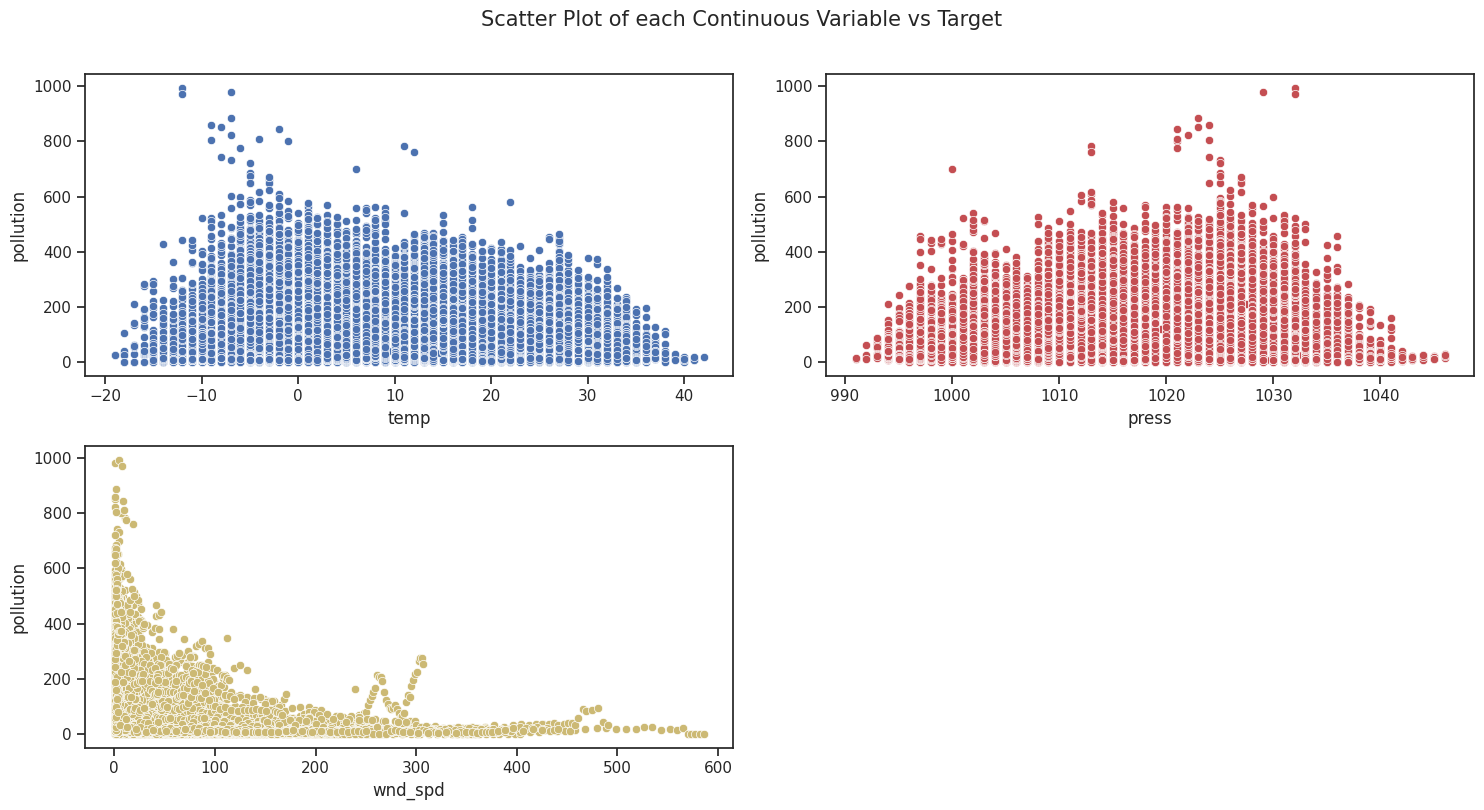

Number of All Scatter Plots = 6


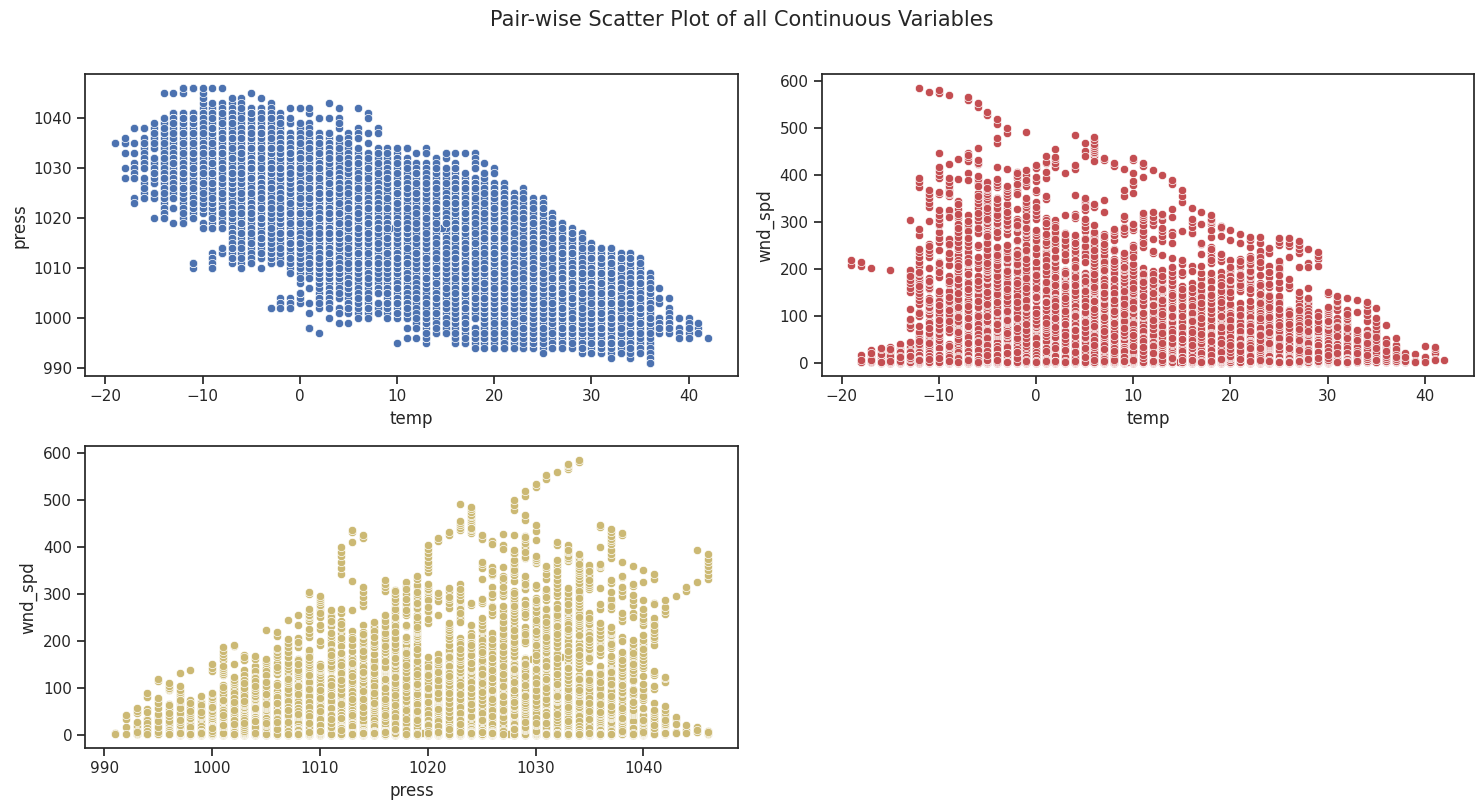

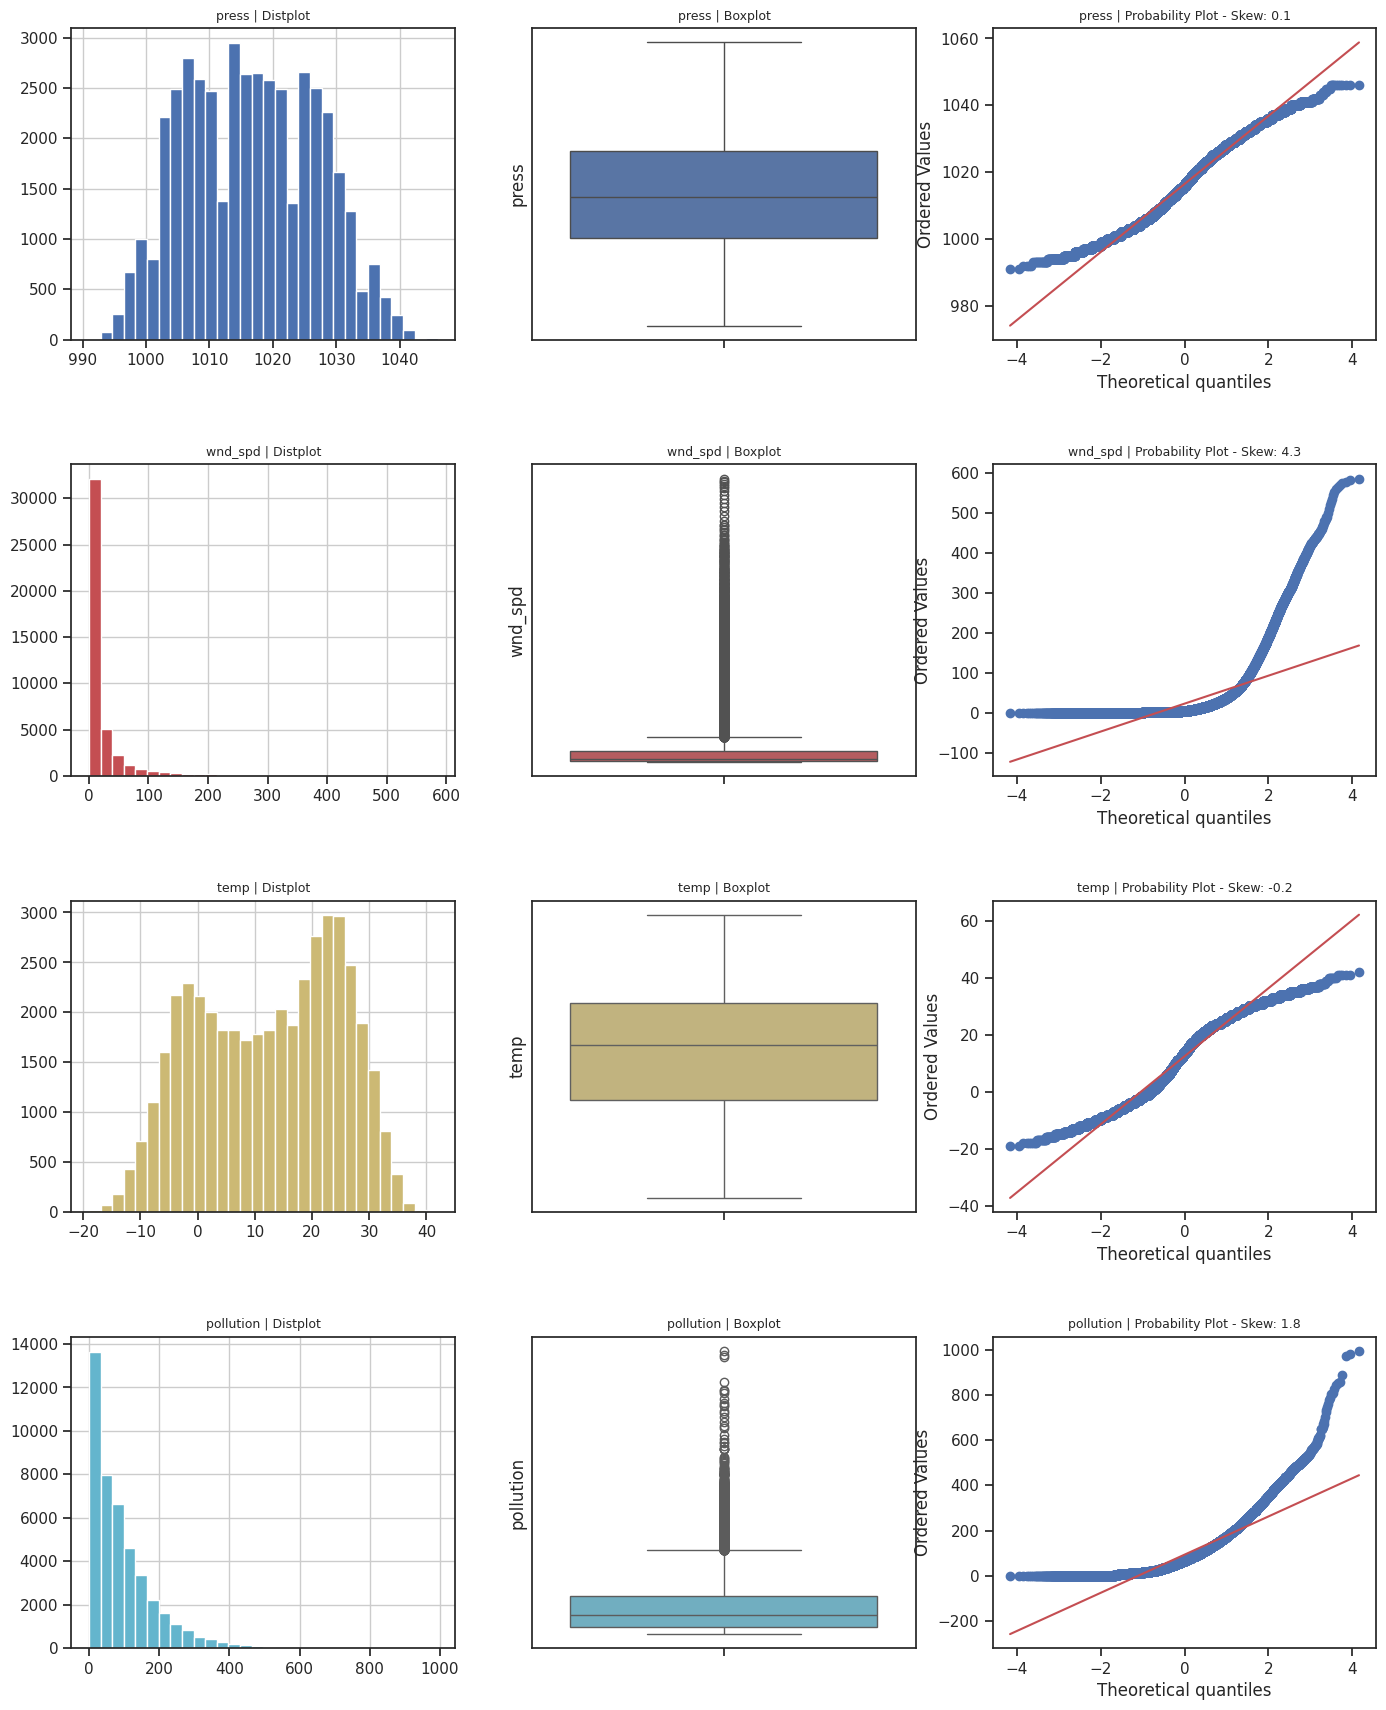

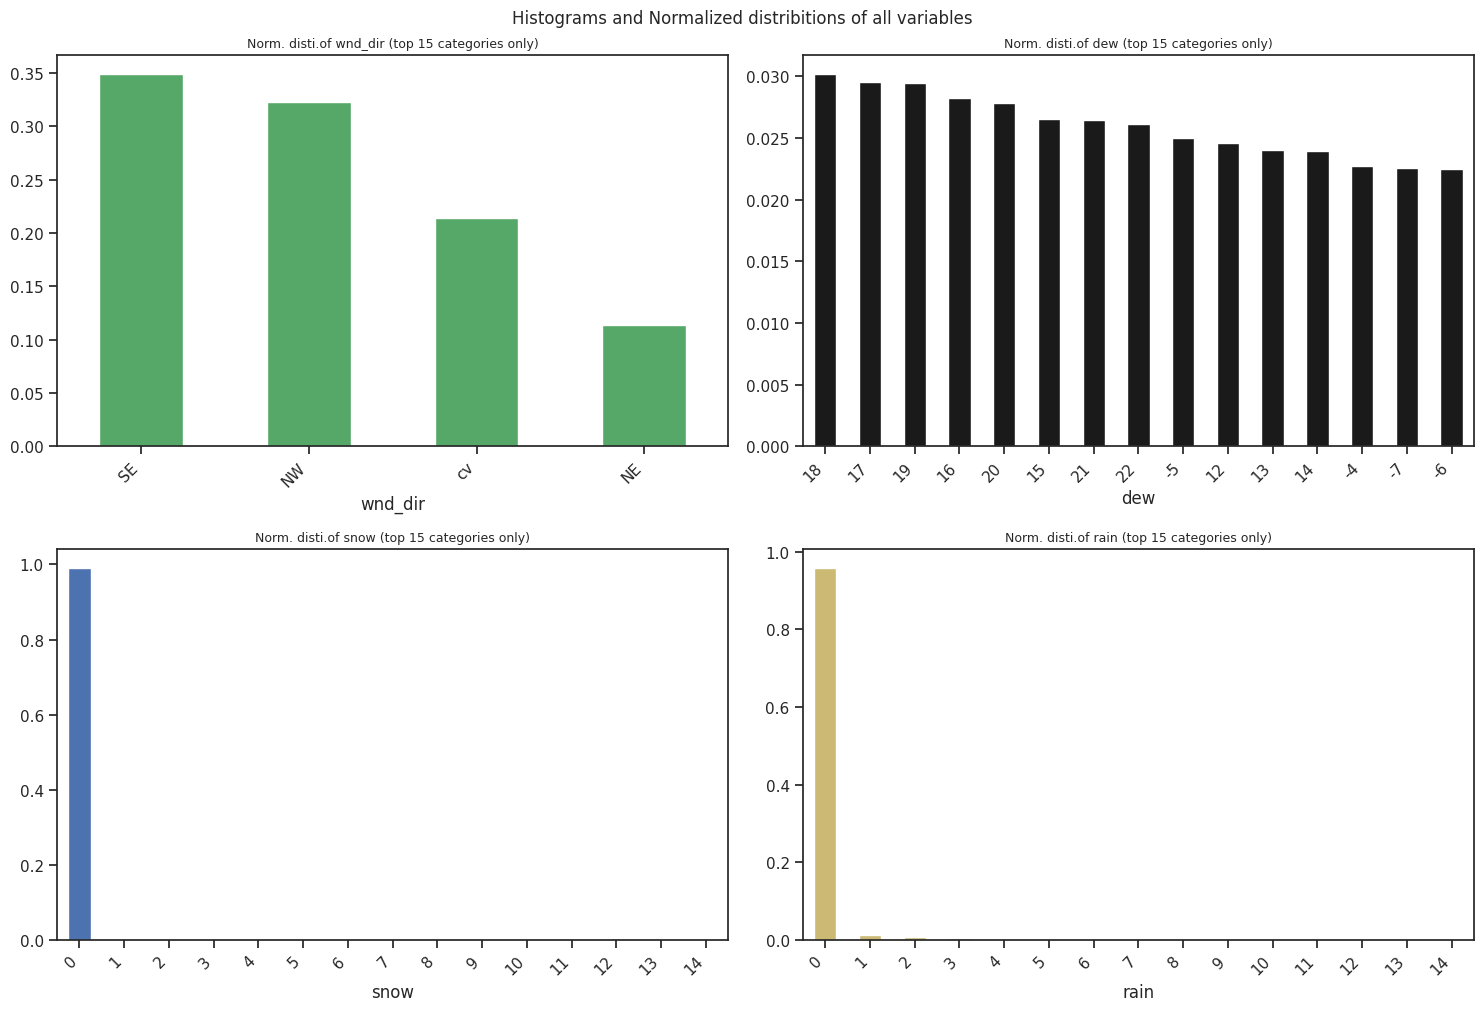

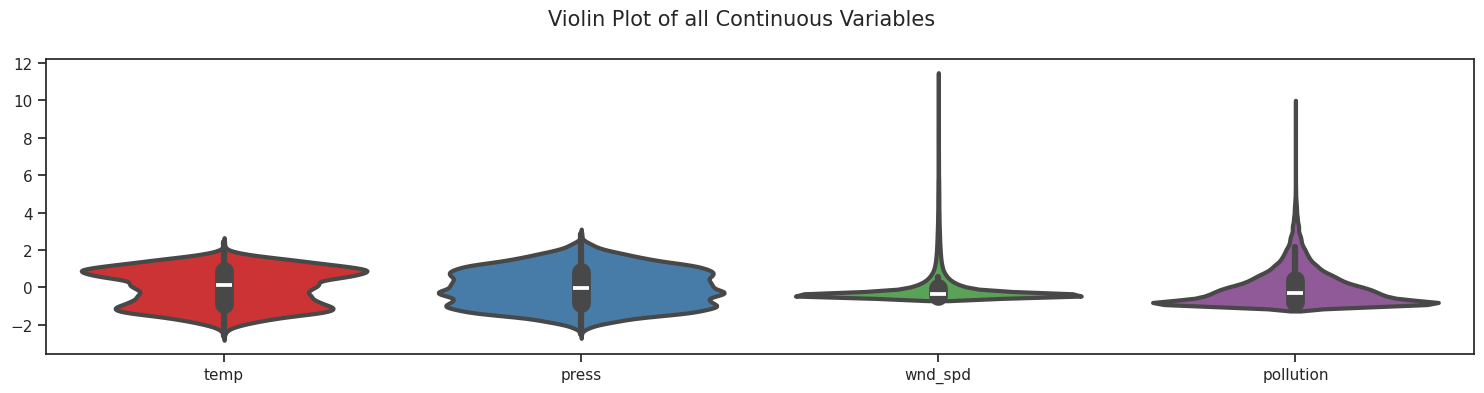

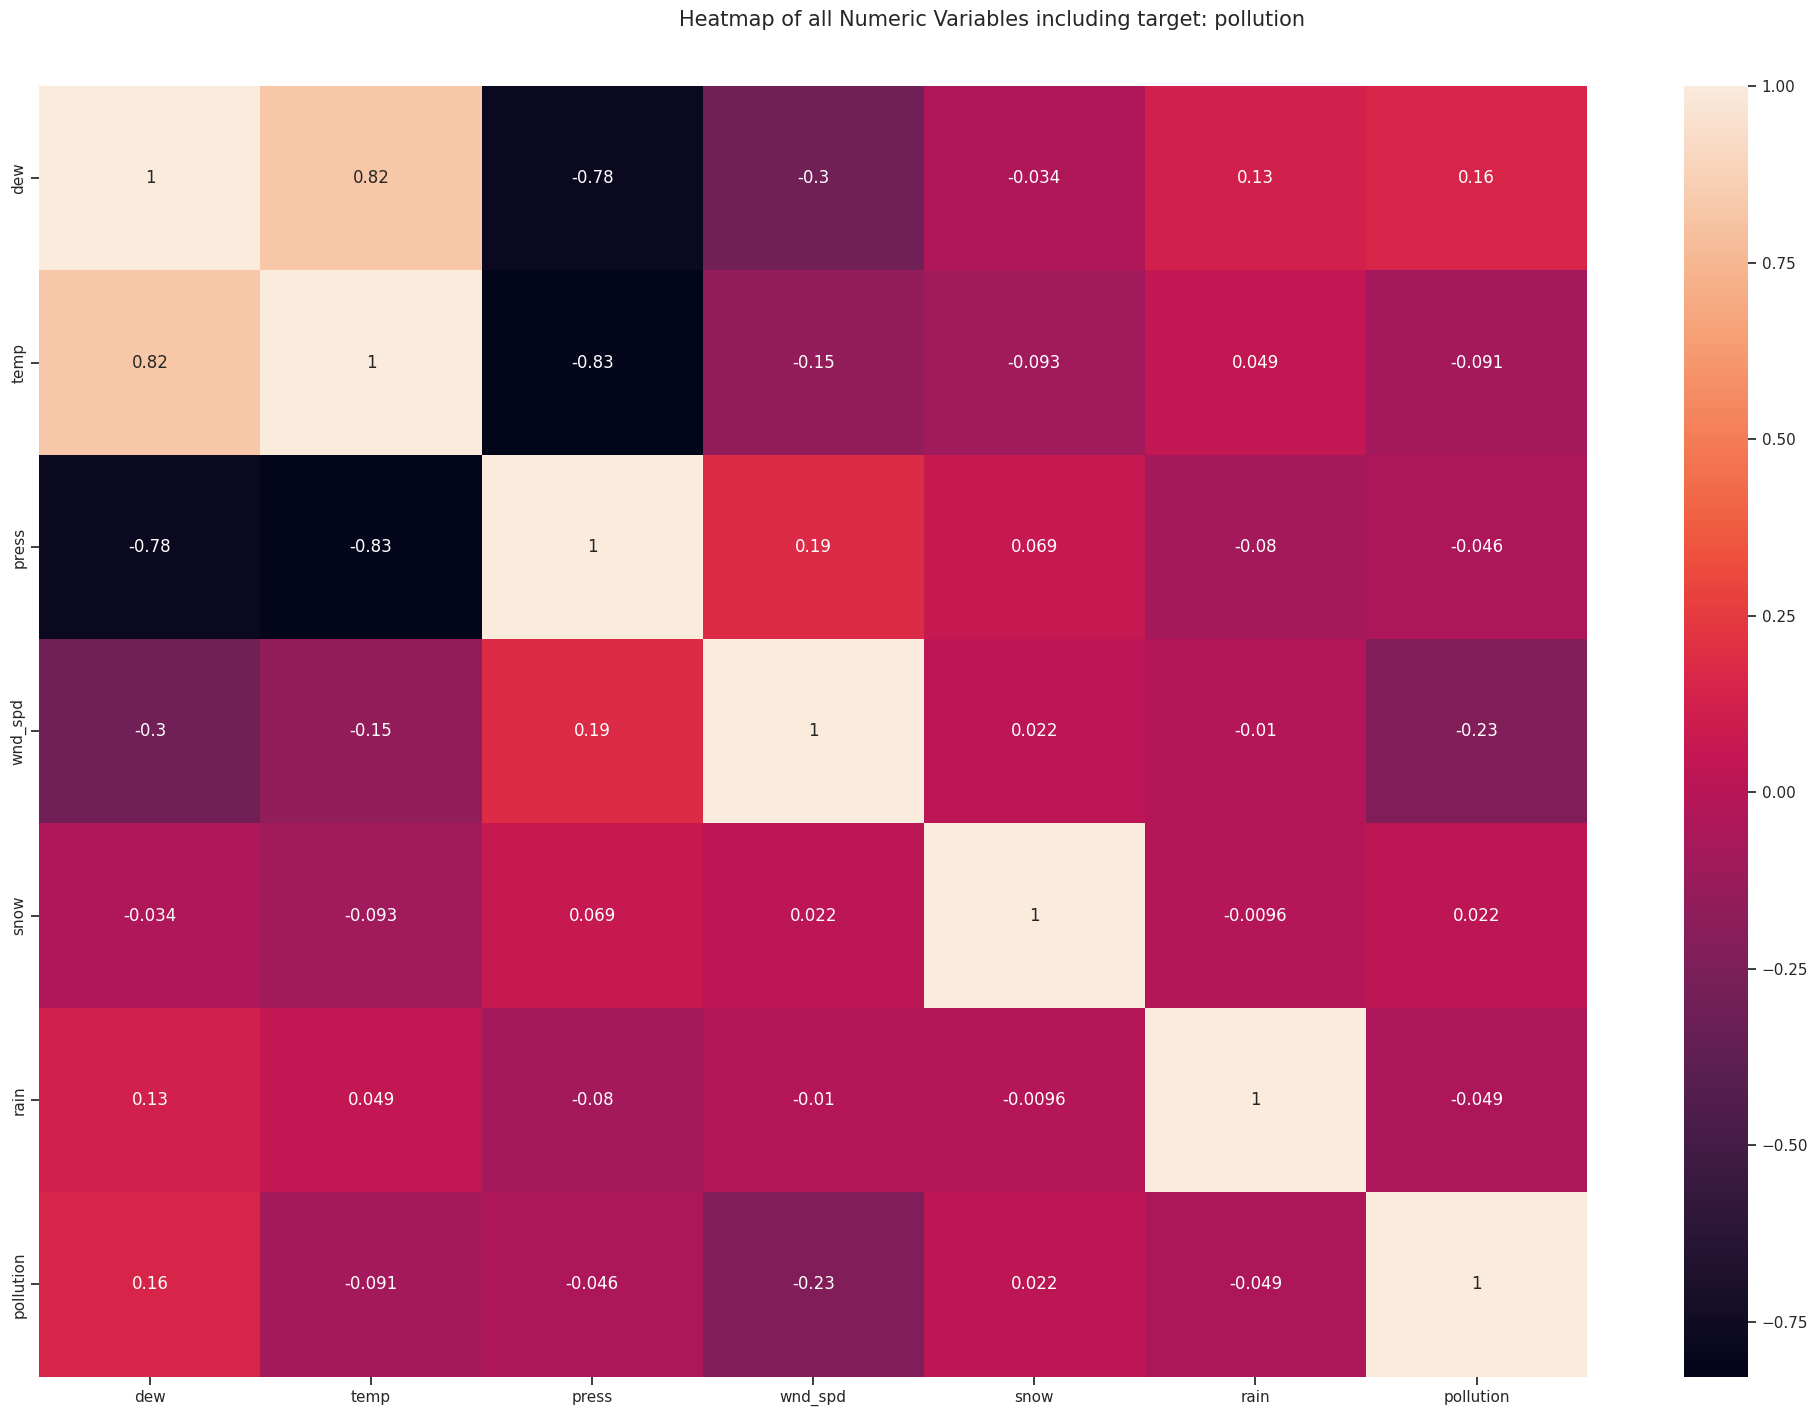

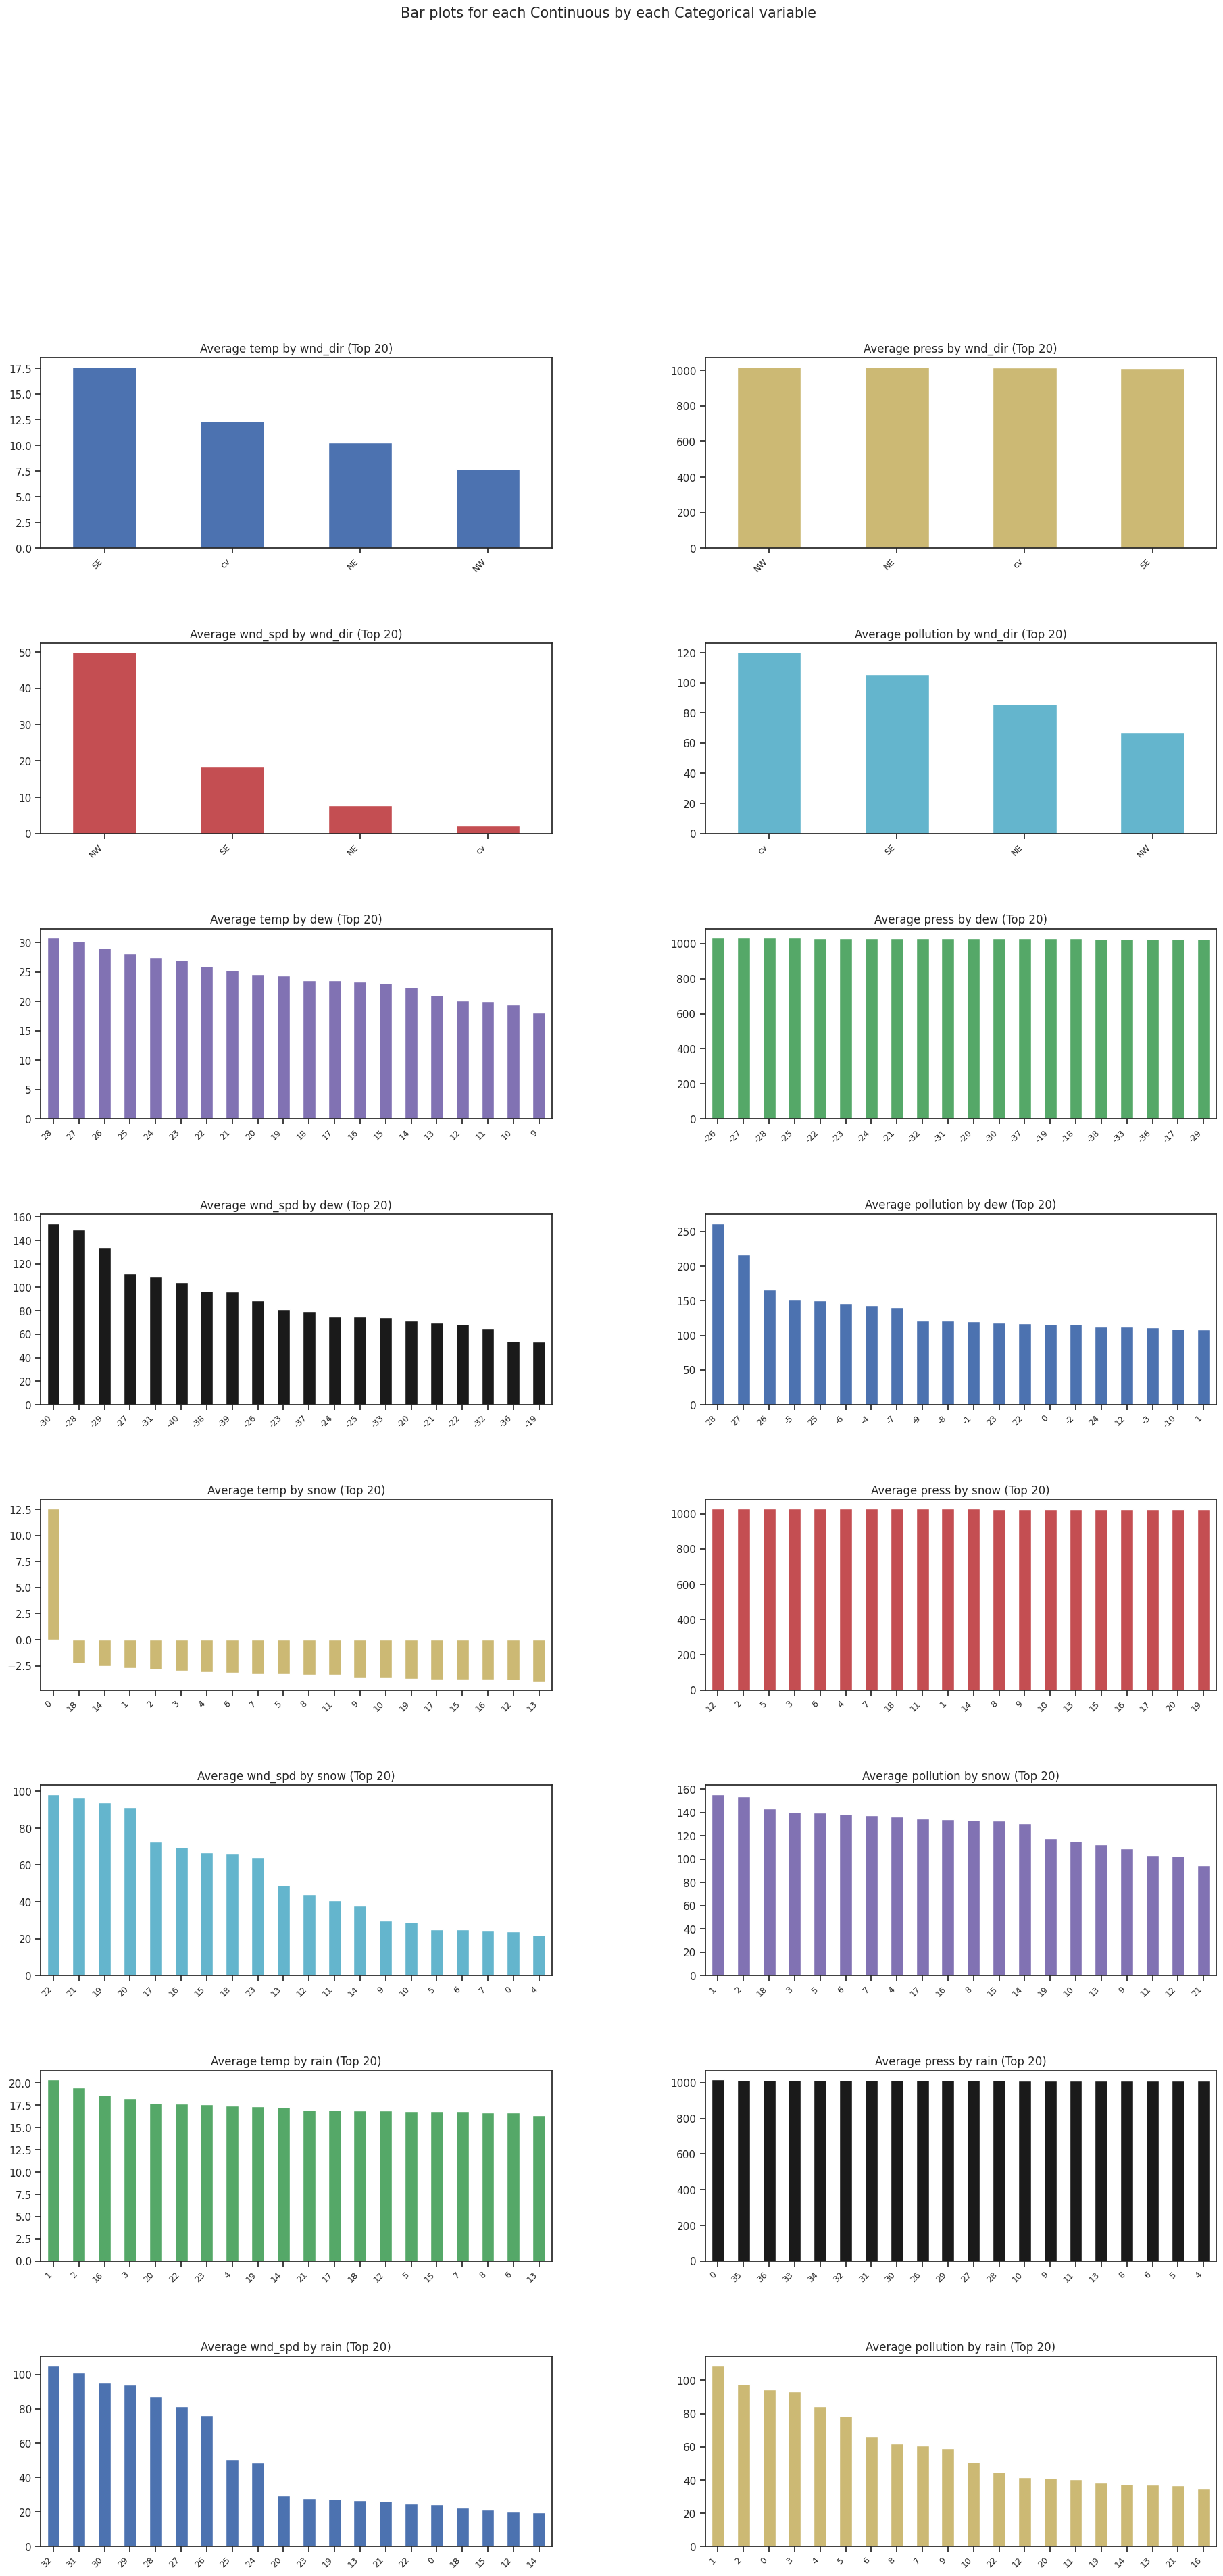

All Plots done
Time to run AutoViz = 11 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [ ]:
# Análisis exploratorio automático (gráfico)
AV = AutoViz_Class()
dataset = AV.AutoViz(url, depVar="pollution") #variable objetivo es polucion

In [ ]:
# Análisis Exploratorio Automático 1 - AutoEDA - Pandas Profiling
profile = ProfileReport(df, title="Pandas Profiling Report")
#profile.to_file("EDA_Report.html")

In [ ]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 37.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Análisis Exploratorio Automático 2 - Auto EDA - Sweetviz
my_report = sweetviz.analyze([pd.read_csv(url),'Dataset'],target_feat="pollution")

                                             |          | [  0%]   00:00 -> (? left)

In [ ]:
# Generación del reporte
my_report.show_html("Report.html")

Report Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
from google.colab import files

# Download the report HTML file
files.download("Report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **AutoML**

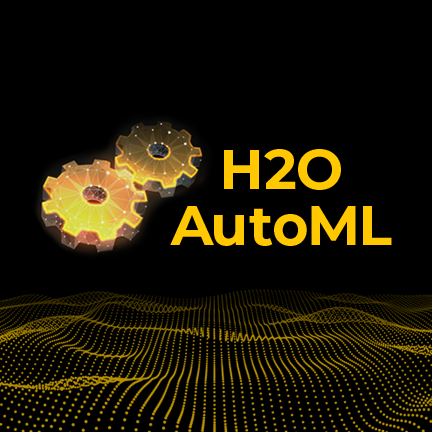

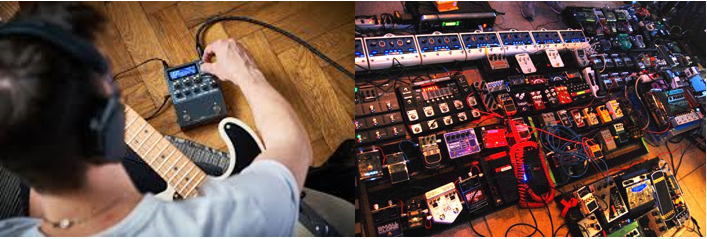

Documentacion de h2O: https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html?utm_source=chatgpt.com

H2O es una libreria de Machine Learning que permite entrenar y comparar modelos de forma bastante simple.

Una de sus principales herramientas es H2O AutoML. Esta funcionalidad prueba automaticamente distintos algoritmos, ajusta modelos y genera un ranking con los mejores resultados.

**Consideraciones de esta librería:**

Tanto en la API de R como en la de Python, AutoML utiliza los mismos argumentos relacionados con los datos, x, y, marco_entrenamiento, marco_validación, que los otros algoritmos H2O. La mayoría de las veces, todo lo que se necesita hacer es especificar los argumentos de los datos. Luego es posible configurar valores para **max_runtime_secs** y/o **max_models** para establecer límites explícitos de tiempo o número de modelos en su ejecución.


![picture](https://www.ericsson.com/4a949f/assets/global/qbank/2020/10/14/machine-learning-workflow-124321d41d8cd98f00b204e9800998ecf8427e.png?w=1410)

[Fuente del Ejemplo](https://github.com/SeanPLeary/time-series-h2o-automl-example/blob/master/h2o_automl_example_with_multivariate_time_series.ipynb)

Para modelar la serie temporal con métodos tradicionales de aprendizaje supervisado, se deben pre-procesar los datos. Creamos las variables lagueadas mediante la función [time_series_to_supervised](https://machinelearningmastery.com/.convert-time-series-supervised-learning-problem-python/). La función tiene los siguientes parámetros:


*   data = dataframe
*   n_lags = lags pasados
*   n_lags = lags futuros
*   selLag = selecciona una variable específica del lag pasado
*   selFut = selecciona una variable específica del lag futuro
*   dropnan = borra las líneas con NaN









In [ ]:
#lag, sumatorias, indices

def time_series_to_supervised(data, n_lag=1, n_fut=1, selLag=None, selFut=None, dropnan=True):
    """
    Converts a time series to a supervised learning data set by adding time-shifted prior and future period
    data as input or output (i.e., target result) columns for each period
    :param data:  a series of periodic attributes as a list or NumPy array
    :param n_lag: number of PRIOR periods to lag as input (X); generates: Xa(t-1), Xa(t-2); min= 0 --> nothing lagged
    :param n_fut: number of FUTURE periods to add as target output (y); generates Yout(t+1); min= 0 --> no future periods
    :param selLag:  only copy these specific PRIOR period attributes; default= None; EX: ['Xa', 'Xb' ]
    :param selFut:  only copy these specific FUTURE period attributes; default= None; EX: ['rslt', 'xx']
    :param dropnan: True= drop rows with NaN values; default= True
    :return: a Pandas DataFrame of time series data organized for supervised learning
    NOTES:
    (1) The current period's data is always included in the output.
    (2) A suffix is added to the original column names to indicate a relative time reference: e.g., (t) is the current
        period; (t-2) is from two periods in the past; (t+1) is from the next period
    (3) This is an extension of Jason Brownlee's series_to_supervised() function, customized for MFI use
    """
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    origNames = df.columns
    cols, names = list(), list()
    # include all current period attributes
    cols.append(df.shift(0))
    names += [('%s' % origNames[j]) for j in range(n_vars)]

    # lag any past period attributes (t-n_lag,...,t-1)
    n_lag = max(0, n_lag)  # force valid number of lag periods
    for i in range(n_lag, 0, -1):
        suffix= '(t-%d)' % i
        if (None == selLag):   # copy all attributes from PRIOR periods?
            cols.append(df.shift(i))
            names += [('%s%s' % (origNames[j], suffix)) for j in range(n_vars)]
        else:
            for var in (selLag):
                cols.append(df[var].shift(i))
                names+= [('%s%s' % (var, suffix))]

    # include future period attributes (t+1,...,t+n_fut)
    n_fut = max(n_fut, 0)  # force valid number of future periods to shift back
    for i in range(1, n_fut + 1):
        suffix= '(t+%d)' % i
        if (None == selFut):  # copy all attributes from future periods?
            cols.append(df.shift(-i))
            names += [('%s%s' % (origNames[j], suffix)) for j in range(n_vars)]
        else:  # copy only selected future attributes
            for var in (selFut):
                cols.append(df[var].shift(-i))
                names += [('%s%s' % (var, suffix))]
    # combine everything
    agg = concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values introduced by lagging
    if dropnan:
        agg.dropna(inplace=True)
    return agg


In [ ]:
# Se aplica la función time_series_to_supervised
df_processed = time_series_to_supervised(df, n_lag=1, n_fut=1 , selLag=None, selFut=['pollution'], dropnan=True)
df_processed.head(10)
#se ven las dif variables qu ese crearon nuevas

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution(t-1),dew(t-1),temp(t-1),press(t-1),wnd_dir(t-1),wnd_spd(t-1),snow(t-1),rain(t-1),pollution(t+1)
date,,,,,,,,,,,,,,,,,
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0,-16.0,-4.0,1020.0,SE,1.79,0.0,0.0,159.0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0,-15.0,-4.0,1020.0,SE,2.68,0.0,0.0,181.0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0,-11.0,-5.0,1021.0,SE,3.57,0.0,0.0,138.0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0,-7.0,-5.0,1022.0,SE,5.36,1.0,0.0,109.0
2010-01-02 05:00:00,109.0,-7,-6.0,1022.0,SE,7.14,3,0,138.0,-7.0,-5.0,1022.0,SE,6.25,2.0,0.0,105.0
2010-01-02 06:00:00,105.0,-7,-6.0,1023.0,SE,8.93,4,0,109.0,-7.0,-6.0,1022.0,SE,7.14,3.0,0.0,124.0
2010-01-02 07:00:00,124.0,-7,-5.0,1024.0,SE,10.72,0,0,105.0,-7.0,-6.0,1023.0,SE,8.93,4.0,0.0,120.0
2010-01-02 08:00:00,120.0,-8,-6.0,1024.0,SE,12.51,0,0,124.0,-7.0,-5.0,1024.0,SE,10.72,0.0,0.0,132.0
2010-01-02 09:00:00,132.0,-7,-5.0,1025.0,SE,14.30,0,0,120.0,-8.0,-6.0,1024.0,SE,12.51,0.0,0.0,140.0


Incorporar **n_fut** permite agregar columnas al conjunto de datos que representan valores futuros de la serie temporal.

In [ ]:
df_processed.tail(10)

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution(t-1),dew(t-1),temp(t-1),press(t-1),wnd_dir(t-1),wnd_spd(t-1),snow(t-1),rain(t-1),pollution(t+1)
date,,,,,,,,,,,,,,,,,
2014-12-31 13:00:00,11.0,-27,0.0,1032.0,NW,186.38,0,0,17.0,-22.0,0.0,1033.0,NW,177.44,0.0,0.0,9.0
2014-12-31 14:00:00,9.0,-27,1.0,1032.0,NW,196.21,0,0,11.0,-27.0,0.0,1032.0,NW,186.38,0.0,0.0,11.0
2014-12-31 15:00:00,11.0,-26,1.0,1032.0,NW,205.15,0,0,9.0,-27.0,1.0,1032.0,NW,196.21,0.0,0.0,8.0
2014-12-31 16:00:00,8.0,-23,0.0,1032.0,NW,214.09,0,0,11.0,-26.0,1.0,1032.0,NW,205.15,0.0,0.0,9.0
2014-12-31 17:00:00,9.0,-22,-1.0,1033.0,NW,221.24,0,0,8.0,-23.0,0.0,1032.0,NW,214.09,0.0,0.0,10.0
2014-12-31 18:00:00,10.0,-22,-2.0,1033.0,NW,226.16,0,0,9.0,-22.0,-1.0,1033.0,NW,221.24,0.0,0.0,8.0
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0,-22.0,-2.0,1033.0,NW,226.16,0.0,0.0,10.0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0,-23.0,-2.0,1034.0,NW,231.97,0.0,0.0,10.0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0,-22.0,-3.0,1034.0,NW,237.78,0.0,0.0,8.0


In [ ]:
# Se carga la base
url='https://raw.githubusercontent.com/braiandrago/AST/main/pollution.csv'
df = pd.read_csv(url,index_col=0,parse_dates=True)
df.head()

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
date,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0


In [ ]:
df.tail()

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
date,,,,,,,,
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0
2014-12-31 23:00:00,12.0,-21,-3.0,1034.0,NW,249.85,0,0


In [ ]:
# Se aplica la función time_series_to_supervised
df_processed = time_series_to_supervised(df, n_lag=1, n_fut=1 , selLag=None, selFut=['pollution'], dropnan=True)

In [ ]:
# Separación en entrenamiento (80%) y testeo (20%)
df_processed.reset_index(drop=True,inplace=True) # reseteo el índice
df_train = df_processed.loc[:int(df_processed.shape[0]*0.8),:]
df_test = df_processed.loc[int(df_processed.shape[0]*0.8):,:]

In [ ]:
# Visualziación de la base de entrenamiento
df_train.head()

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution(t-1),dew(t-1),temp(t-1),press(t-1),wnd_dir(t-1),wnd_spd(t-1),snow(t-1),rain(t-1),pollution(t+1)
0,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0,-16.0,-4.0,1020.0,SE,1.79,0.0,0.0,159.0
1,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0,-15.0,-4.0,1020.0,SE,2.68,0.0,0.0,181.0
2,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0,-11.0,-5.0,1021.0,SE,3.57,0.0,0.0,138.0
3,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0,-7.0,-5.0,1022.0,SE,5.36,1.0,0.0,109.0
4,109.0,-7,-6.0,1022.0,SE,7.14,3,0,138.0,-7.0,-5.0,1022.0,SE,6.25,2.0,0.0,105.0


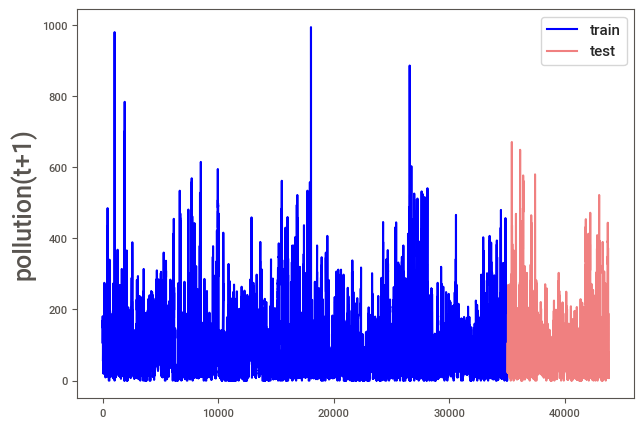

In [ ]:
# Se grafican las bases de entrenamiento y testeo juntas
plt.plot(df_train.index,df_train['pollution(t+1)'],color='blue')
plt.plot(df_test.index,df_test['pollution(t+1)'],color='lightcoral')
plt.ylabel('pollution(t+1)',fontsize=18)
plt.legend(['train','test'])
plt.show()

Se utiliza la librería H2O para el modelado.

[Documentación de H2O](https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html)

[Breve Introducción a H2O](https://www.datacamp.com/community/tutorials/h2o-automl?utm_source=adwords_ppc&utm_campaignid=1455363063&utm_adgroupid=65083631748&utm_device=c&utm_keyword=&utm_matchtype=b&utm_network=s&utm_adpostion=&utm_creative=278443377086&utm_targetid=aud-763347114660:dsa-429603003980&utm_loc_interest_ms=&utm_loc_physical_ms=1000073&gclid=CjwKCAjwtpGGBhBJEiwAyRZX2ibtKYEghiaov8V72GeEZ5pd8KmeyWlT-IIdYtQxk4RfPE-7h4KQLBoCP8sQAvD_BwE)

**Inicializamos una instancia del servidor de H2O**

In [ ]:
# Se inicializa la sesión ## lib h20 -- corre varioas modelos -- hay que inicializar, se crea un local host y le tenemos que dar nuestra dataset (train y test)
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpyurf696s
  JVM stdout: /tmp/tmpyurf696s/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpyurf696s/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,18 days
H2O_cluster_name:,H2O_from_python_unknownUser_71hfe8
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
# Se convierten los dataframe de pandas en h2o frames
hf_train = h2o.H2OFrame(df_train) # se transforman los datos para que h2o lo procese
hf_test = h2o.H2OFrame(df_test)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Análisis exploratorio del h2o frame de entrenamiento
hf_train.describe()

Rows:35039
Cols:17

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution(t-1),dew(t-1),temp(t-1),press(t-1),wnd_dir(t-1),wnd_spd(t-1),snow(t-1),rain(t-1),pollution(t+1)
type,int,int,int,real,enum,real,int,int,int,int,int,real,enum,real,int,int,int
mins,0.0,-33.0,-19.0,991.0,,0.45,0.0,0.0,0.0,-33.0,-19.0,991.0,,0.45,0.0,0.0,0.0
mean,93.35837209966049,1.773109963183872,12.154370843916785,1016.3996404007004,,24.963884528667965,0.057478809326750153,0.20988041896172863,93.36139730015174,1.773224121692951,12.154056908016868,1016.3998116384574,,24.96000656411427,0.057478809326750153,0.20988041896172863,93.35483318587804
maxs,994.0,28.0,41.0,1046.0,,585.6,27.0,36.0,994.0,28.0,41.0,1046.0,,585.6,27.0,36.0,994.0
sigma,91.90981126115078,14.494809359874703,12.306906922191068,10.386335259832615,,51.316324996508314,0.7738490378684302,1.4899490055843665,91.90923984452935,14.494653624689587,12.30717870443259,10.38634515672728,,51.31294167537916,0.7738490378684302,1.4899490055843665,91.9100945289003
zeros,1946,636,882,0,,0,34708,33523,1946,636,882,0,,0,34708,33523,1946
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,148.0,-15.0,-4.0,1020.0,SE,2.68,0.0,0.0,129.0,-16.0,-4.0,1020.0,SE,1.79,0.0,0.0,159.0
1,159.0,-11.0,-5.0,1021.0,SE,3.57,0.0,0.0,148.0,-15.0,-4.0,1020.0,SE,2.68,0.0,0.0,181.0
2,181.0,-7.0,-5.0,1022.0,SE,5.36,1.0,0.0,159.0,-11.0,-5.0,1021.0,SE,3.57,0.0,0.0,138.0


In [ ]:
# Se define el target y la base de entrenamiento
y = 'pollution(t+1)'
X = hf_train.columns
X.remove(y)

In [ ]:
# Configuración de los parámetros de entrenamiento
aml = H2OAutoML(nfolds=0,max_runtime_secs = 180,seed = 42, verbosity="info", exclude_algos=['StackedEnsemble']) # Se excluyeron los ensambles
# Inicio del entrenamiento
aml.train(x = X,
          y = y,
          training_frame = hf_train,
          leaderboard_frame = hf_test)

#aca ejecuta los modelos y da el ganador

AutoML progress: |
13:27:09.827: Project: AutoML_1_20251213_132709
13:27:09.832: Cross-validation disabled by user: no fold column nor nfolds > 1.
13:27:09.834: Setting stopping tolerance adaptively based on the training frame: 0.005342249270903391
13:27:09.835: Build control seed: 42
13:27:09.848: Since cross-validation is disabled, and validation frame(s) were not provided, automatically split the training data into training, validation frame(s) in the ratio 90/10/0.
13:27:10.486: training frame: Frame key: AutoML_1_20251213_132709_training_Key_Frame__upload_96c992ee549b654278c690a55cec43e5.hex    cols: 17    rows: 31531  chunks: 1    size: 1025824  checksum: -4553007266590669598
13:27:10.497: validation frame: Frame key: AutoML_1_20251213_132709_validation_Key_Frame__upload_96c992ee549b654278c690a55cec43e5.hex    cols: 17    rows: 3508  chunks: 1    size: 109448  checksum: 2216354446303237350
13:27:10.497: leaderboard frame: Frame key: Key_Frame__upload_8a1296d0e8aa9fd2a5e2299a98b04

,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
,80.0,80.0,65785.0,7.0,7.0,7.0,10.0,122.0,60.7375
,timestamp,duration,number_of_trees,training_rmse,training_mae,training_deviance,validation_rmse,validation_mae,validation_deviance
,2025-12-13 13:28:05,0.098 sec,0.0,91.9228688,69.0387192,8449.8138086,91.7820822,68.9126148,8423.9506136
,2025-12-13 13:28:06,0.584 sec,5.0,58.1603186,43.2110049,3382.6226645,58.8584704,43.2860663,3464.3195350
,2025-12-13 13:28:06,1.090 sec,10.0,40.0973960,28.8107885,1607.8011656,41.3602836,28.9086785,1710.6730575
,2025-12-13 13:28:07,1.591 sec,15.0,31.6559093,21.4399905,1002.0965959,33.3582404,21.5606307,1112.7722010
,2025-12-13 13:28:07,2.039 sec,20.0,27.4849891,17.3452160,755.4246272,29.6191982,17.5483471,877.2969032
,2025-12-13 13:28:07,2.390 sec,25.0,25.2216122,14.8859212,636.1297229,27.7554798,15.1589217,770.3666586
,2025-12-13 13:28:08,2.625 sec,30.0,24.1672797,13.6430601,584.0574062,26.8155437,13.9440971,719.0733859
,2025-12-13 13:28:08,2.836 sec,35.0,23.5966994,13.0082145,556.8042243,26.3832700,13.3634257,696.0769374


In [ ]:
# Listado de los modelos ganadores
lb = aml.leaderboard
lb

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_2_AutoML_3_20250707_235430,23.3881,547.001,12.3422,0.440159,547.001
GBM_1_AutoML_3_20250707_235430,23.404,547.749,12.4013,nan,547.749
GBM_3_AutoML_3_20250707_235430,23.4361,549.252,12.477,nan,549.252
GBM_grid_1_AutoML_3_20250707_235430_model_6,23.498,552.154,12.4313,nan,552.154
XGBoost_grid_1_AutoML_3_20250707_235430_model_4,23.5245,553.404,12.5892,0.440177,553.404
GBM_grid_1_AutoML_3_20250707_235430_model_2,23.5283,553.582,12.5355,nan,553.582
GBM_grid_1_AutoML_3_20250707_235430_model_1,23.5902,556.498,12.275,0.432842,556.498
XGBoost_grid_1_AutoML_3_20250707_235430_model_6,23.6203,557.919,12.6898,nan,557.919
GBM_5_AutoML_3_20250707_235430,23.7728,565.146,12.3716,0.43513,565.146
XRT_1_AutoML_3_20250707_235430,23.7909,566.009,12.9714,0.458641,566.009


El modelo ganador es un Gradient Boosting, se elije aquel modelo que tenga mejores medidas de precisión. Definición de las medidas de precisión:

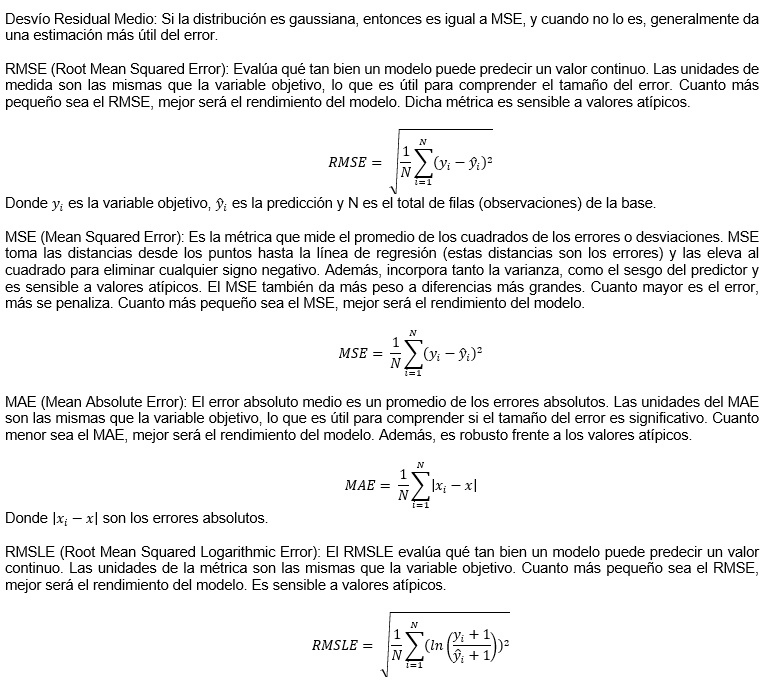

Info adicional de medidas de precisión: [link1](https://stats.stackexchange.com/questions/194453/interpreting-accuracy-results-for-an-arima-model-fit) [link2](https://www.youtube.com/watch?v=KzHJXdFJSIQ)

In [ ]:
# Se elige el modelo ganador
leader_model = aml.leader

In [ ]:
# Se realizan las predicciones en la base de testeo
hf_test_predict = leader_model.predict(hf_test)

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Previsualización de las predicciones
hf_test_predict.head(5)

predict
22.4058
23.6734
53.8992
63.1399
68.5483


In [ ]:
# Predicción vs Valores Reales
df_results = pd.DataFrame()
df_results['ground_truth'] = df_test['pollution(t+1)'].reset_index(drop=True) # valores reales
df_results['predictions'] = h2o.as_list(hf_test_predict,use_pandas=True) # predicciones
df_results.head()

,ground_truth,predictions
0,24.0,22.405826
1,53.0,23.673376
2,65.0,53.899170
3,70.0,63.139855
4,79.0,68.548301


In [ ]:
# Medidas de precisión
perf = aml.leader.model_performance(hf_test)
perf

ModelMetricsRegression: gbm
** Reported on test data. **

MSE: 547.0014660627872
RMSE: 23.38806246919114
MAE: 12.342223026479374
RMSLE: 0.44015853960128626
Mean Residual Deviance: 547.0014660627872

In [ ]:
# Listado de modelos
model_ids = list(aml.leaderboard['model_id'].as_data_frame().iloc[:,0])
model_ids

['GBM_2_AutoML_1_20250707_232505',
 'GBM_1_AutoML_1_20250707_232505',
 'GBM_3_AutoML_1_20250707_232505',
 'GBM_grid_1_AutoML_1_20250707_232505_model_6',
 'XGBoost_grid_1_AutoML_1_20250707_232505_model_4',
 'GBM_grid_1_AutoML_1_20250707_232505_model_2',
 'GBM_grid_1_AutoML_1_20250707_232505_model_1',
 'XGBoost_grid_1_AutoML_1_20250707_232505_model_6',
 'GBM_5_AutoML_1_20250707_232505',
 'XRT_1_AutoML_1_20250707_232505',
 'GBM_4_AutoML_1_20250707_232505',
 'GBM_grid_1_AutoML_1_20250707_232505_model_5',
 'DRF_1_AutoML_1_20250707_232505',
 'GBM_grid_1_AutoML_1_20250707_232505_model_7',
 'XGBoost_3_AutoML_1_20250707_232505',
 'GLM_1_AutoML_1_20250707_232505',
 'GBM_grid_1_AutoML_1_20250707_232505_model_4',
 'DeepLearning_grid_1_AutoML_1_20250707_232505_model_1',
 'XGBoost_grid_1_AutoML_1_20250707_232505_model_2',
 'DeepLearning_1_AutoML_1_20250707_232505',
 'XGBoost_2_AutoML_1_20250707_232505',
 'XGBoost_grid_1_AutoML_1_20250707_232505_model_5',
 'XGBoost_grid_1_AutoML_1_20250707_232505_mod

**DRF** = Distributed Random Forest  
**GBM** = Gradient Boosting Machine   
**XRT** = Extremely randomized trees  
**GLM** = Generalized Linear Model

In [ ]:
# Modelo ganador
h2o.get_model([mid for mid in model_ids if "GBM_1" in mid][0])

,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
,80.0,80.0,151123.0,11.0,15.0,14.575,38.0,201.0,145.2625
,timestamp,duration,number_of_trees,training_rmse,training_mae,training_deviance,validation_rmse,validation_mae,validation_deviance
,2025-07-07 23:25:20,0.106 sec,0.0,91.9228688,69.0387192,8449.8138086,91.7820822,68.9126148,8423.9506136
,2025-07-07 23:25:22,1.816 sec,5.0,58.5187201,43.2766493,3424.4405981,59.1226397,43.4113803,3495.4865219
,2025-07-07 23:25:23,2.858 sec,10.0,41.6191178,29.4437951,1732.1509668,42.7309887,29.5804741,1825.9373933
,2025-07-07 23:25:24,3.581 sec,15.0,32.6309924,21.3607432,1064.7816635,33.9318306,21.4976854,1151.3691262
,2025-07-07 23:25:24,4.245 sec,20.0,28.9343246,17.4400585,837.1951402,30.3537228,17.6243367,921.3484868
,2025-07-07 23:25:25,4.873 sec,25.0,26.8692767,14.9657364,721.9580302,28.2846718,15.1632915,800.0226565
,2025-07-07 23:25:26,5.326 sec,30.0,25.9554236,13.7849342,673.6840120,27.4472926,14.0563107,753.3538717
,2025-07-07 23:25:26,6.058 sec,35.0,25.4946129,13.2031809,649.9752865,27.0645150,13.5517348,732.4879728


In [ ]:
out = h2o.get_model([mid for mid in model_ids if "GBM_1" in mid][0])

In [ ]:
# Parámetros del modelo ganador
out.params

{'model_id': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'schema_name': 'ModelKeyV3',
    'schema_type': 'Key<Model>'},
   'name': 'GBM_1_AutoML_1_20250707_232505',
   'type': 'Key<Model>',
   'URL': '/3/Models/GBM_1_AutoML_1_20250707_232505'},
  'input': None},
 'training_frame': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'schema_name': 'FrameKeyV3',
    'schema_type': 'Key<Frame>'},
   'name': 'AutoML_1_20250707_232505_training_Key_Frame__upload_b015922490956066c25353d961774ab4.hex',
   'type': 'Key<Frame>',
   'URL': '/3/Frames/AutoML_1_20250707_232505_training_Key_Frame__upload_b015922490956066c25353d961774ab4.hex'},
  'input': {'__meta': {'schema_version': 3,
    'schema_name': 'FrameKeyV3',
    'schema_type': 'Key<Frame>'},
   'name': 'AutoML_1_20250707_232505_training_Key_Frame__upload_b015922490956066c25353d961774ab4.hex',
   'type': 'Key<Frame>',
   'URL': '/3/Frames/AutoML_1_20250707_232505_training_Key_Frame__upload_b01592249095

# Residual Analysis

> Residual Analysis plots the fitted values vs residuals on a test dataset. Ideally, residuals should be randomly distributed. Patterns in this plot can indicate potential problems with the model selection, e.g., using simpler model than necessary, not accounting for heteroscedasticity, autocorrelation, etc. Note that if you see "striped" lines of residuals, that is an artifact of having an integer valued (vs a real valued) response variable.

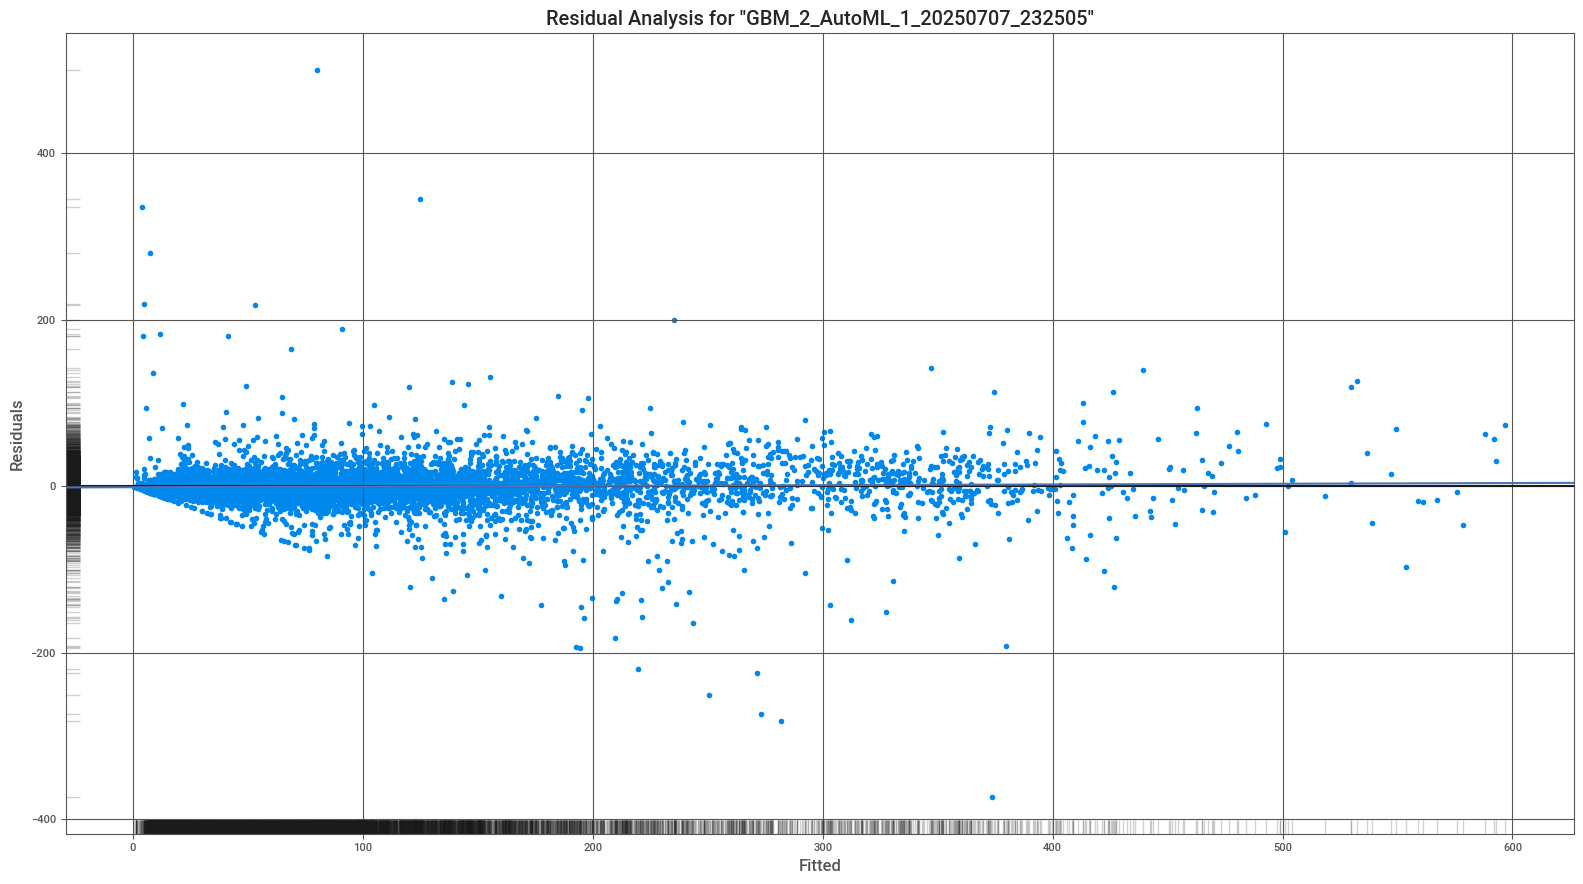

# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

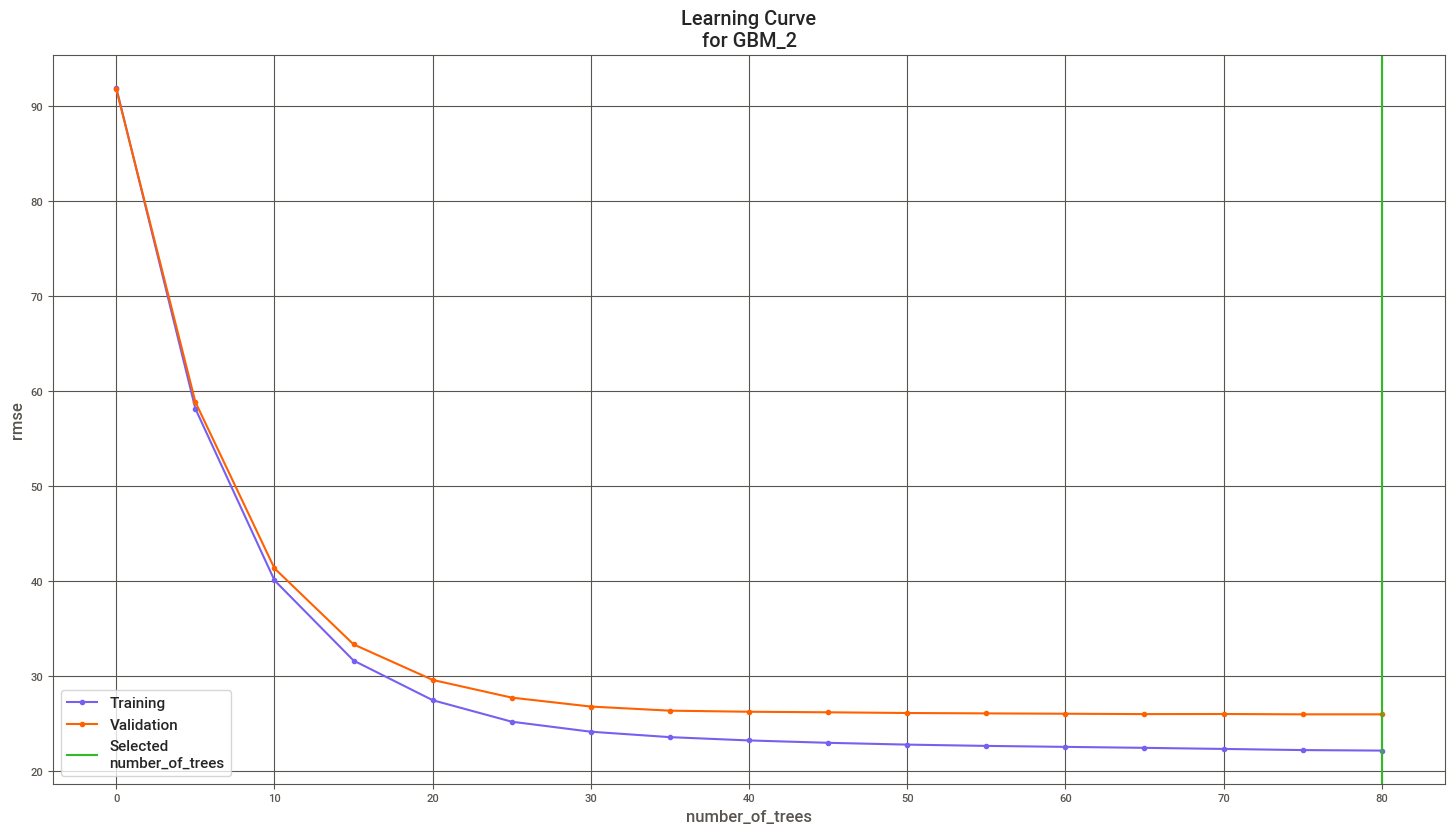

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

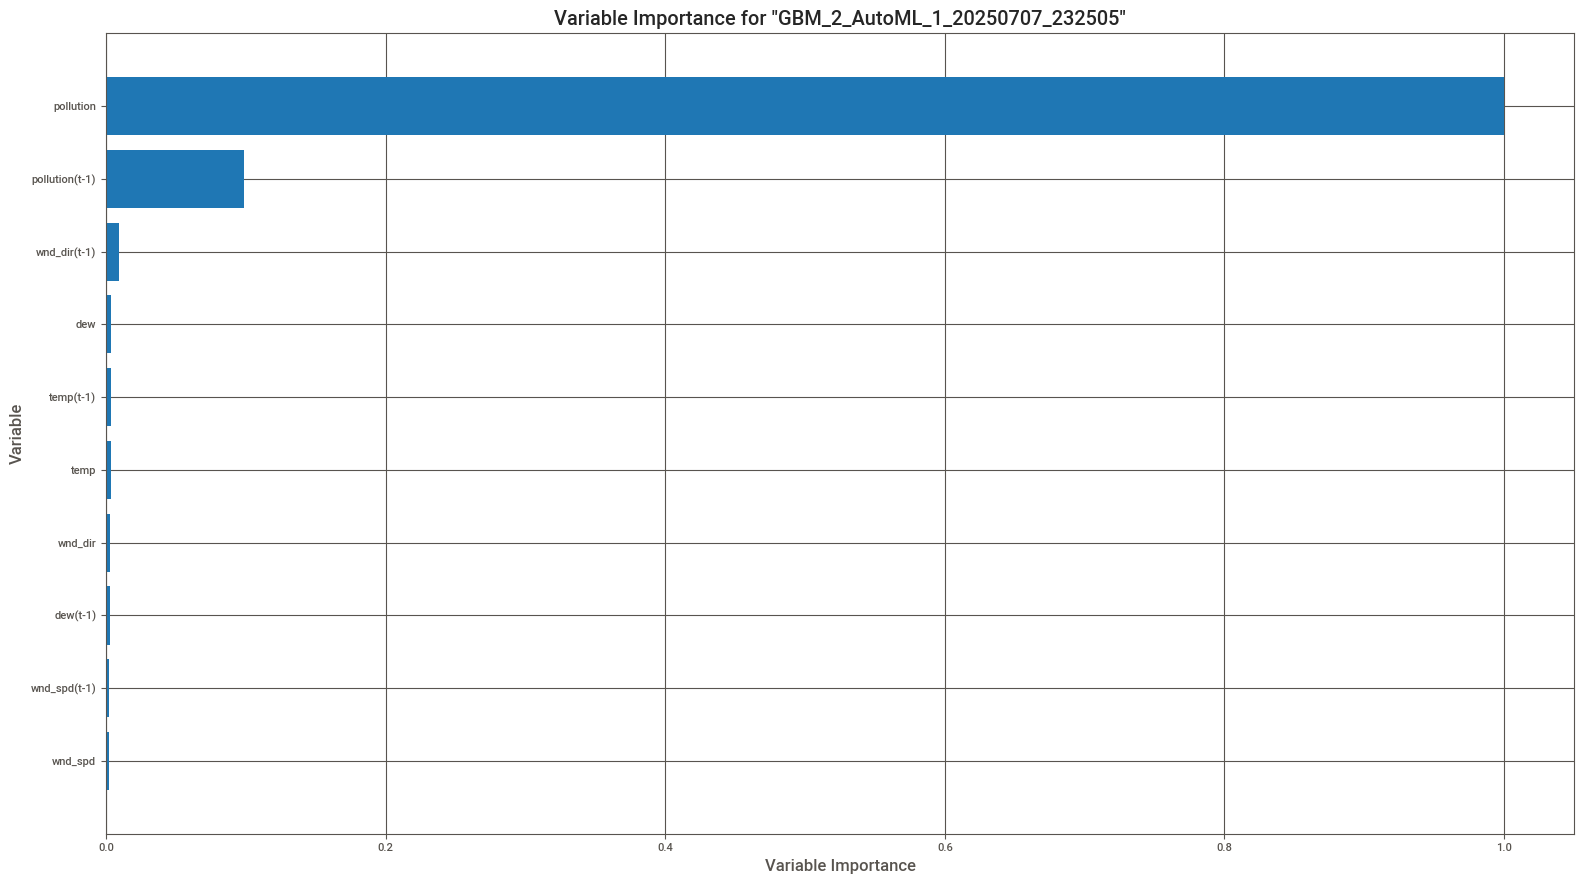

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

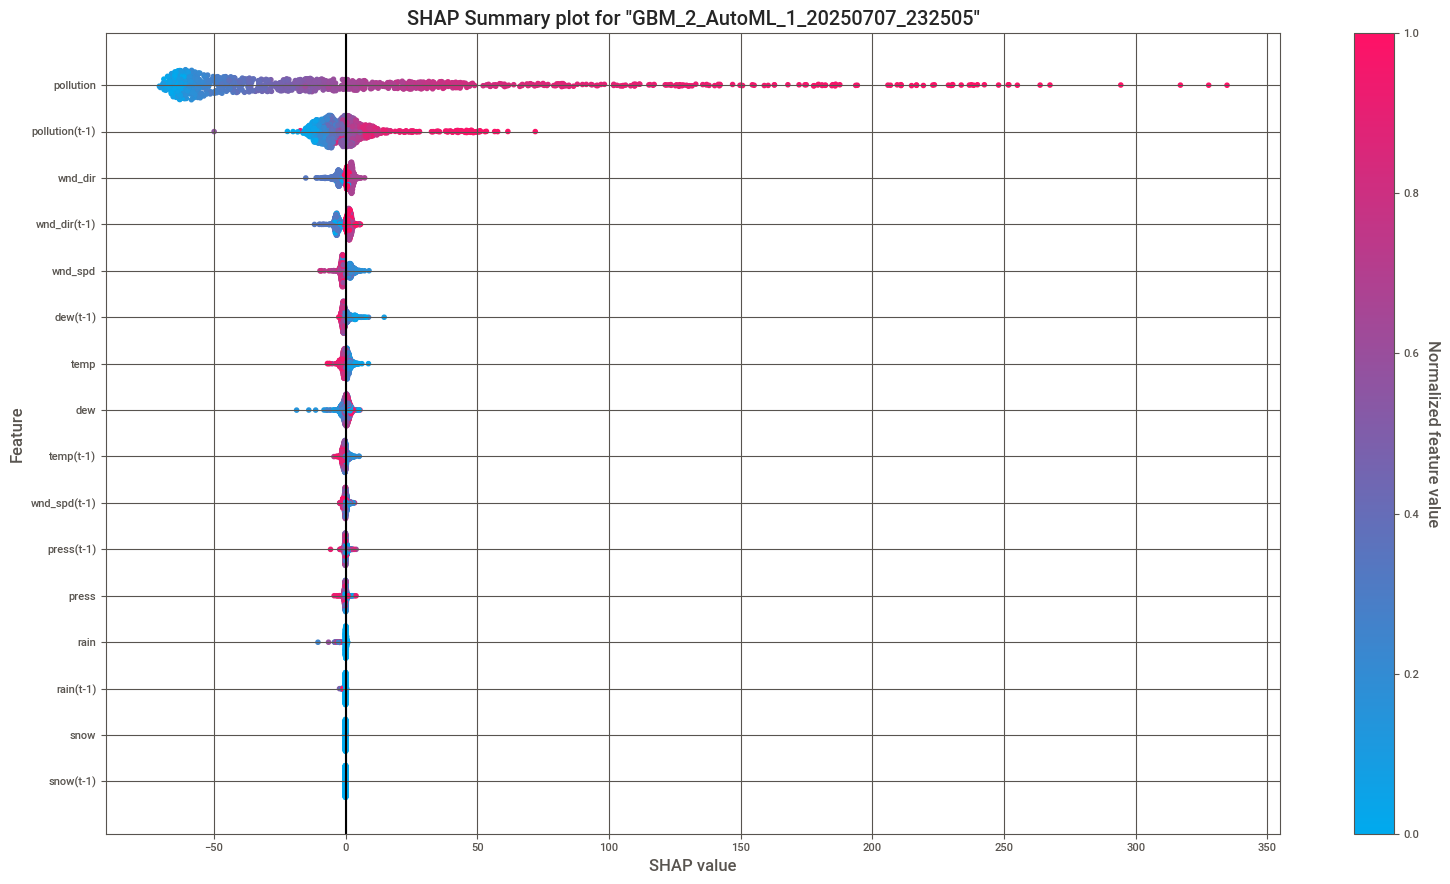

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

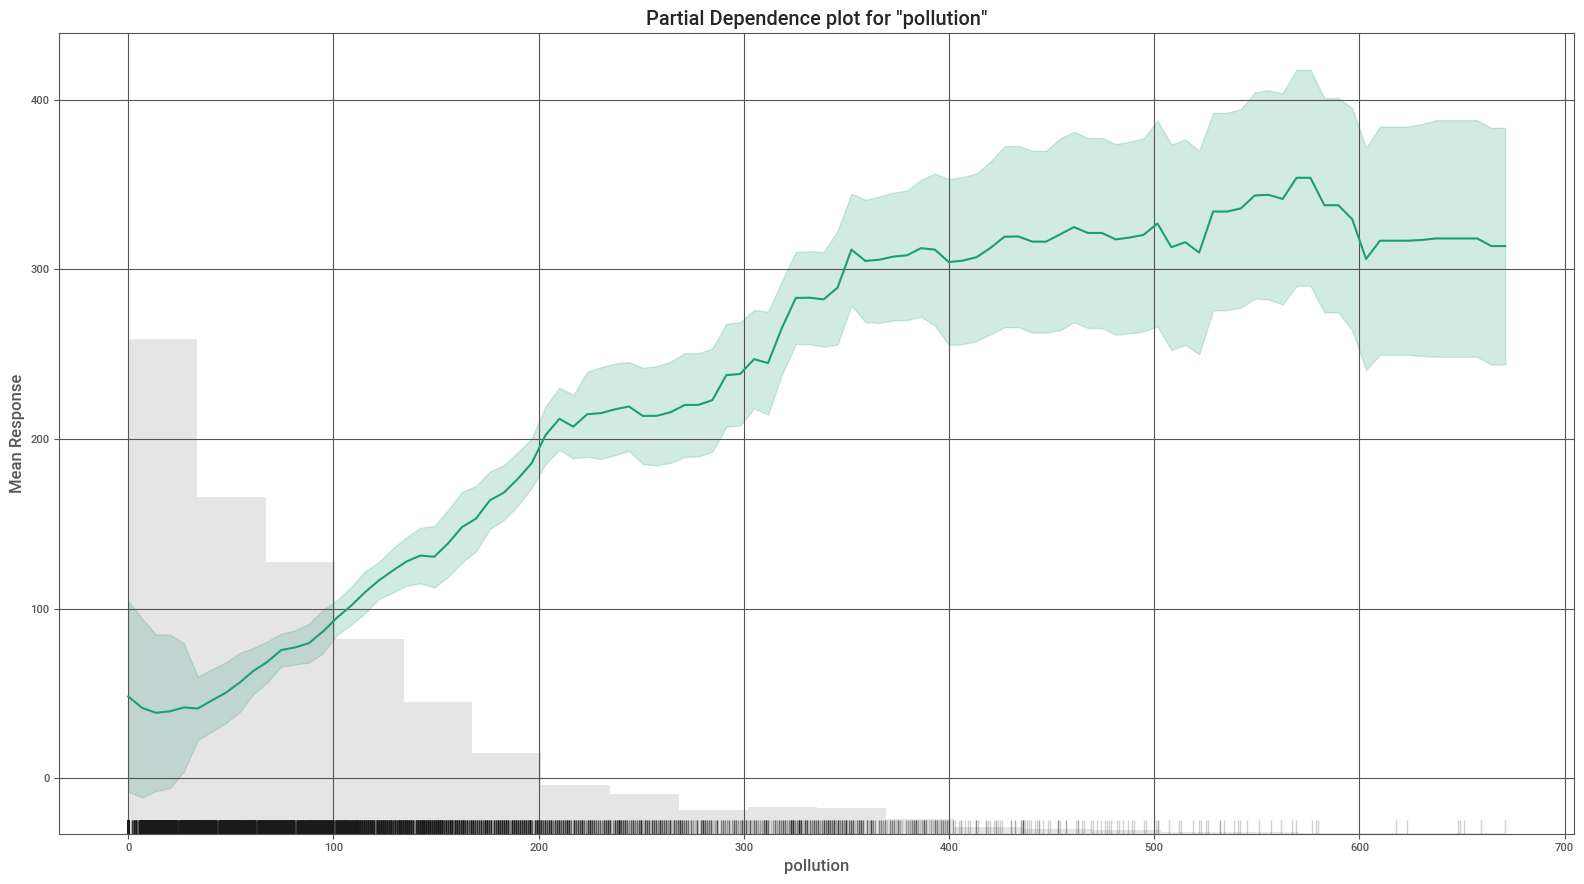

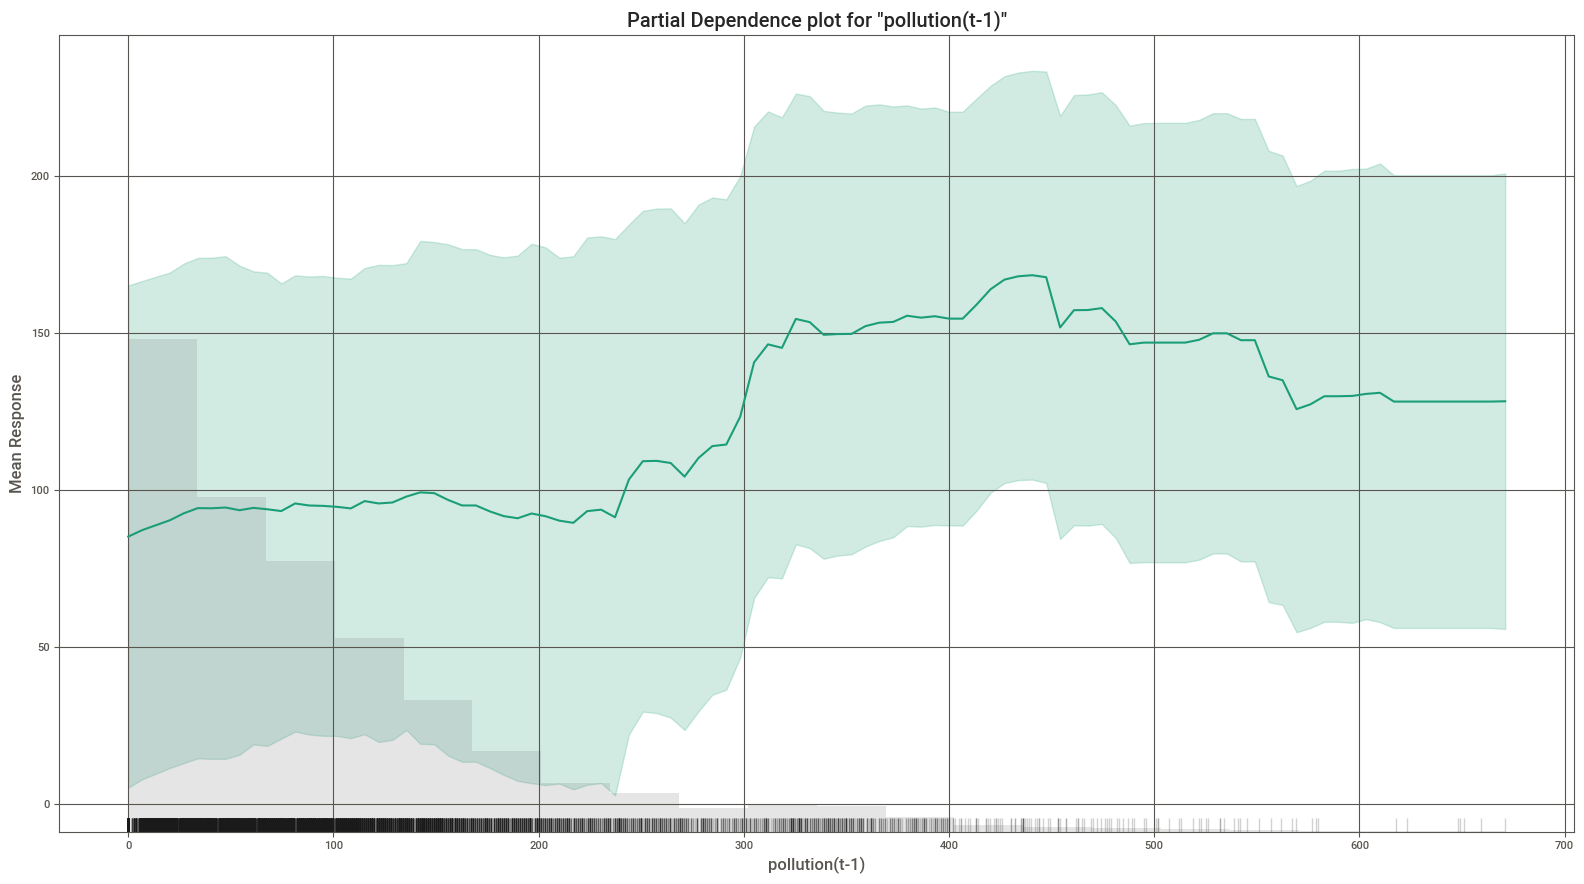

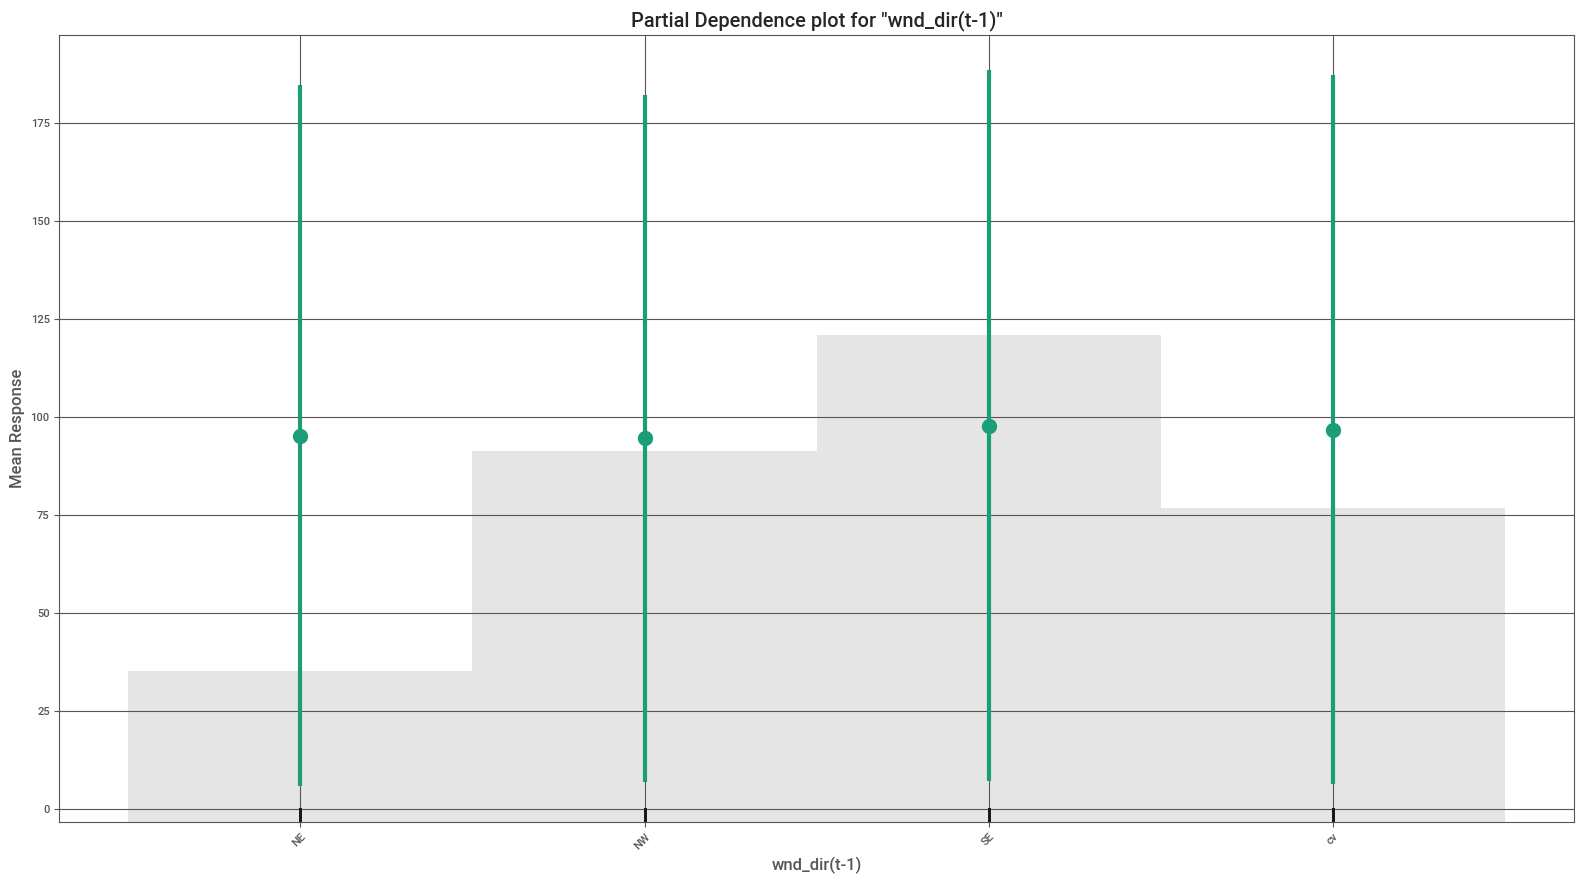

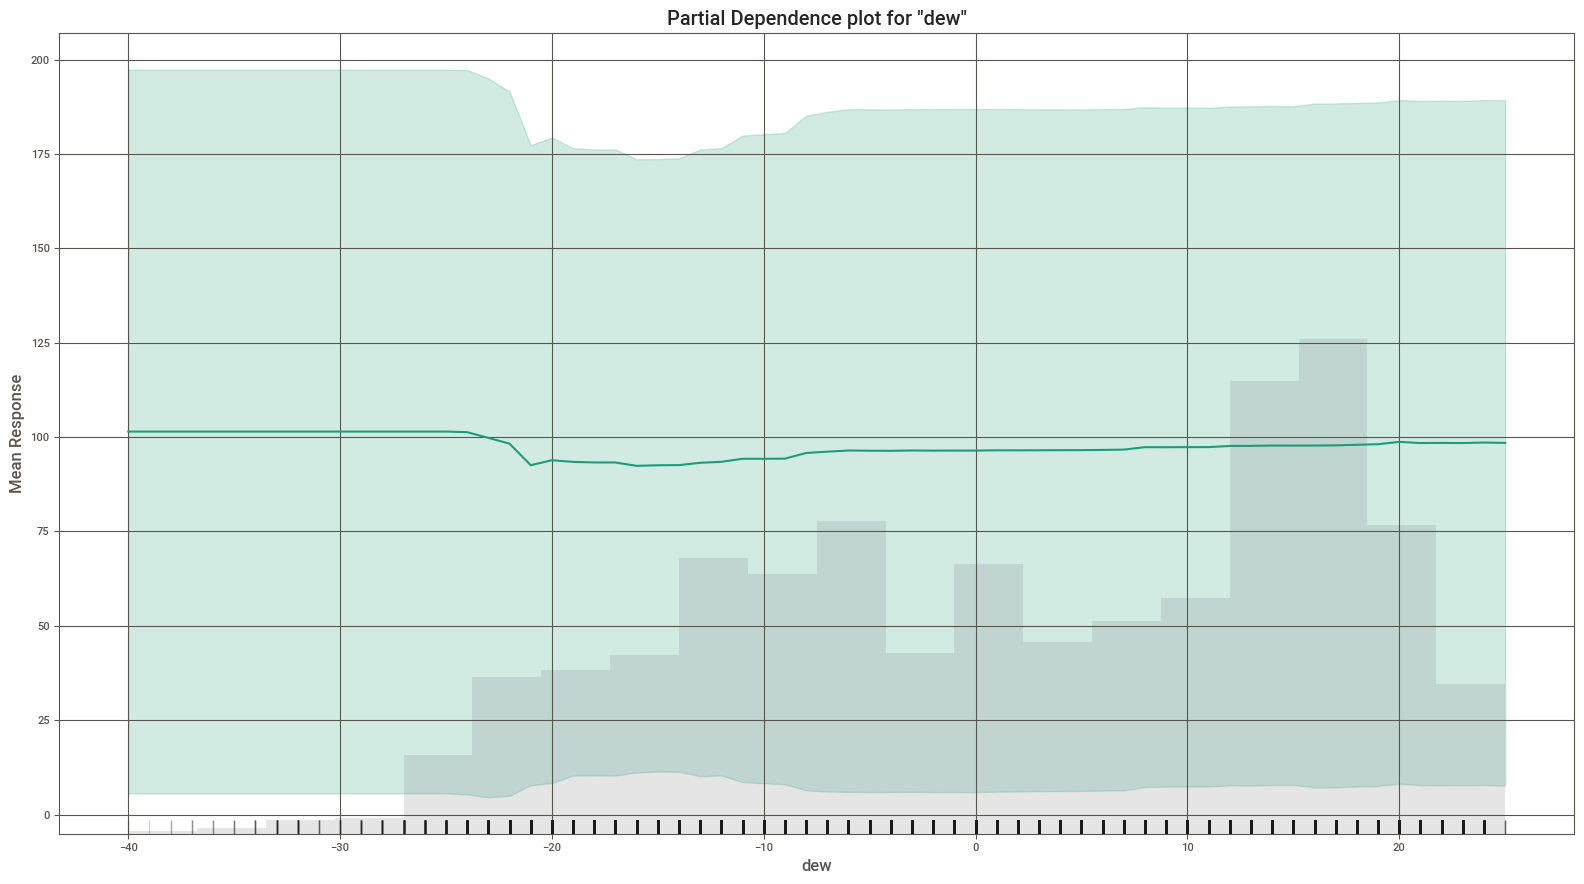

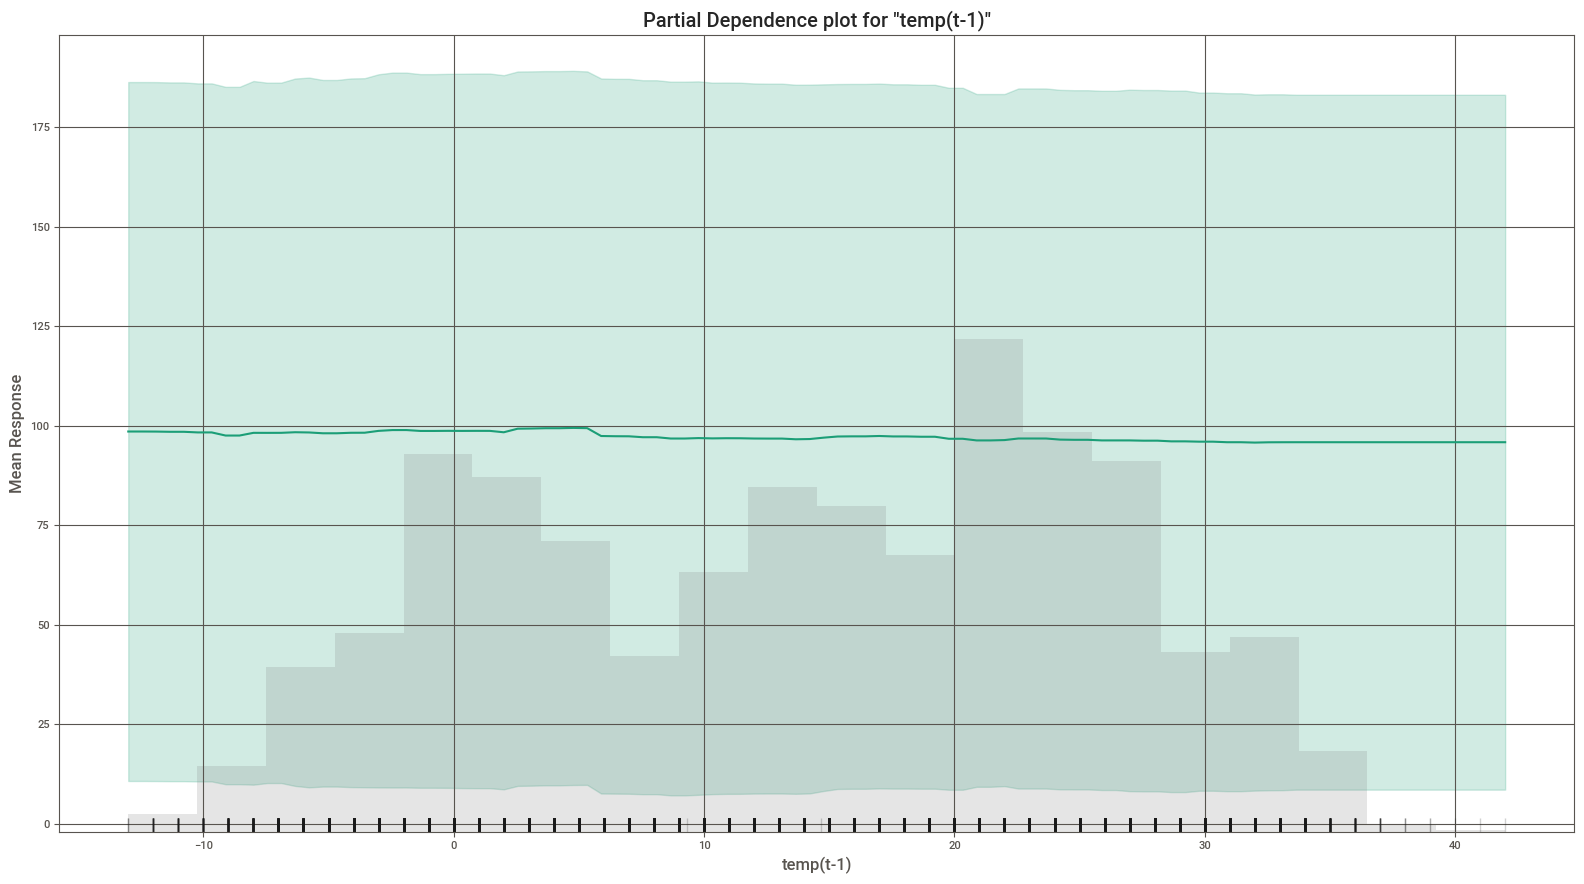

# Individual Conditional Expectation

> An Individual Conditional Expectation (ICE) plot gives a graphical depiction of the marginal effect of a variable on the response. ICE plots are similar to partial dependence plots (PDP); PDP shows the average effect of a feature while ICE plot shows the effect for a single instance. This function will plot the effect for each decile. In contrast to the PDP, ICE plots can provide more insight, especially when there is stronger feature interaction.

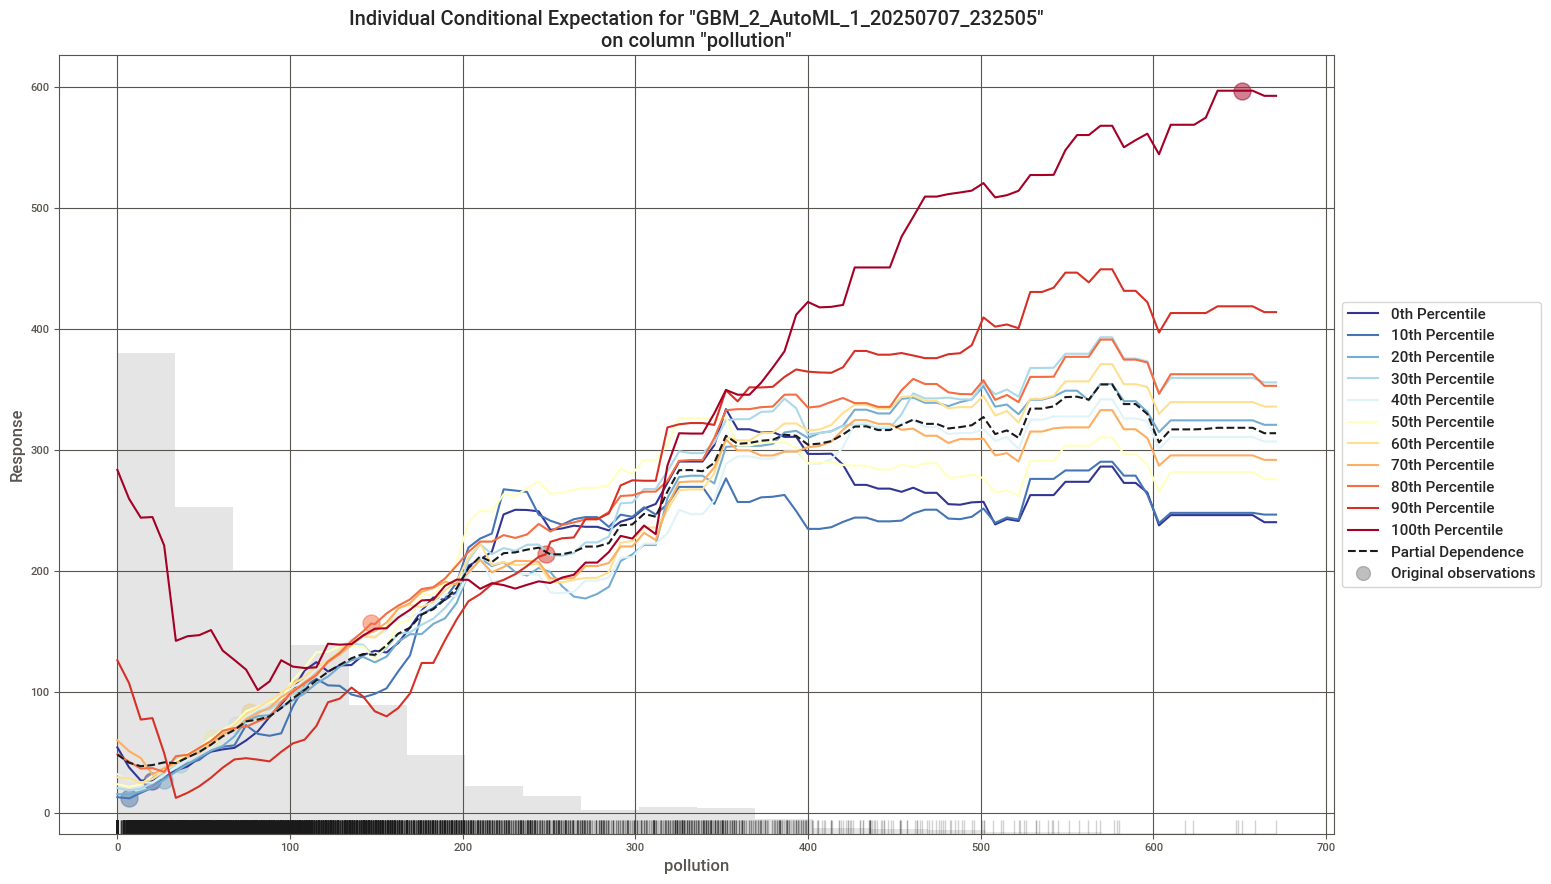

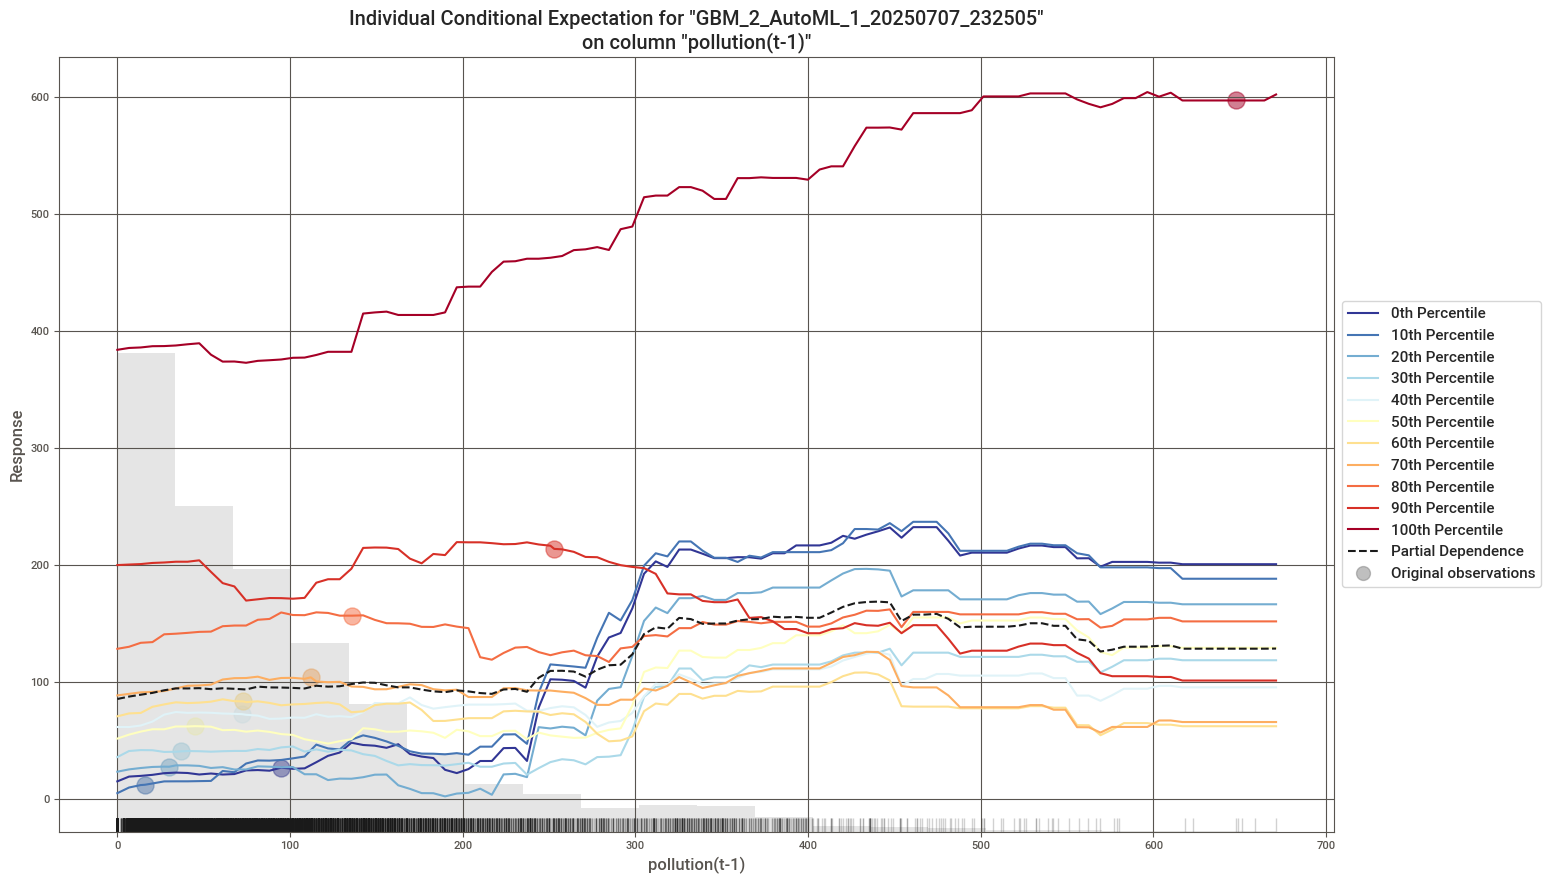

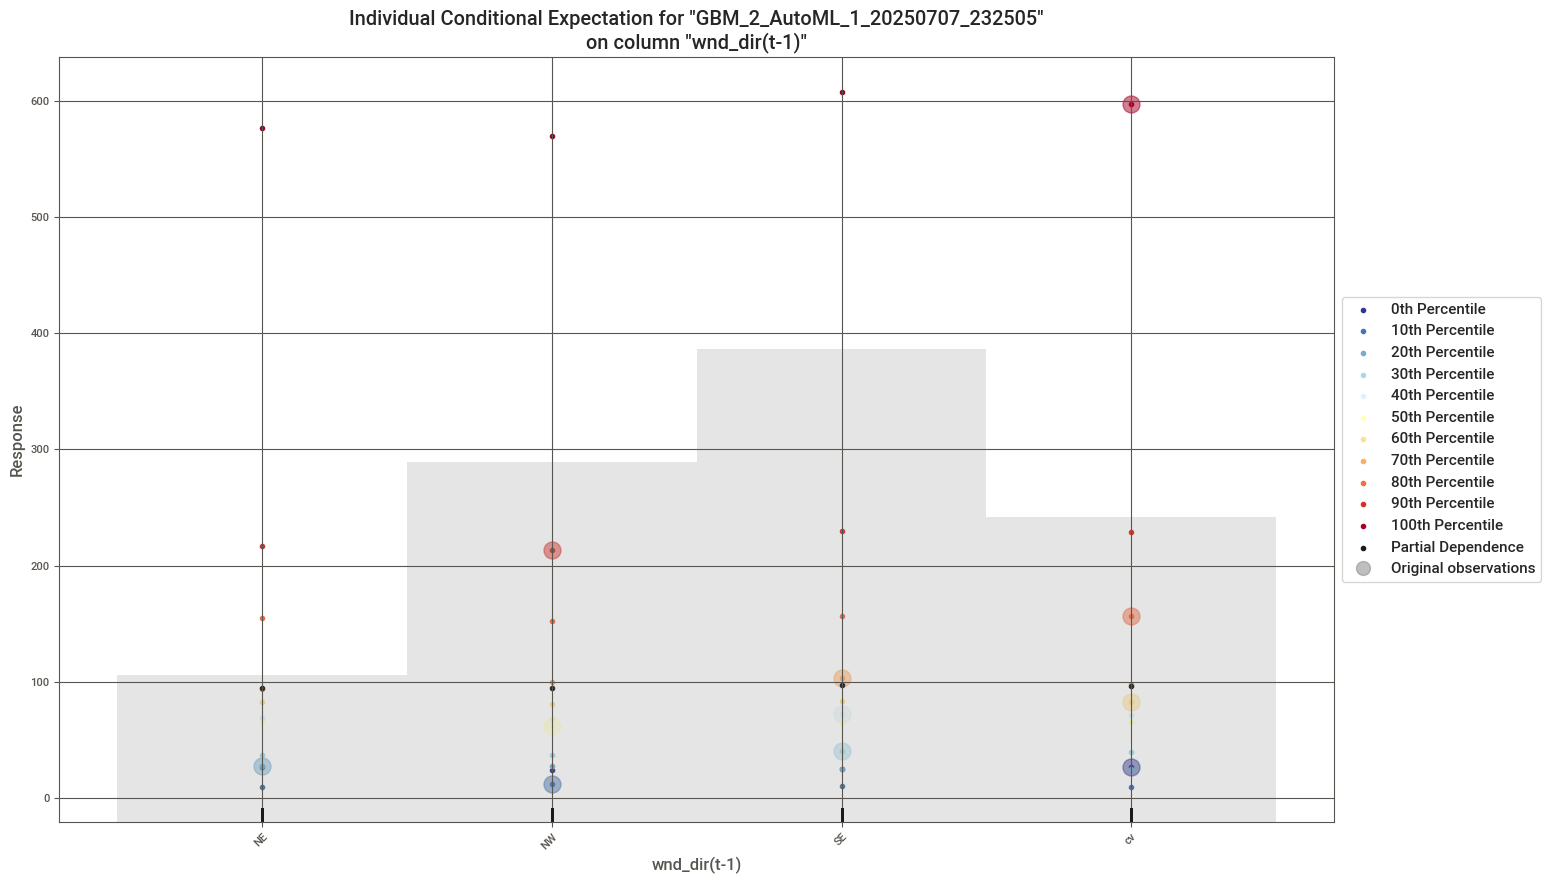

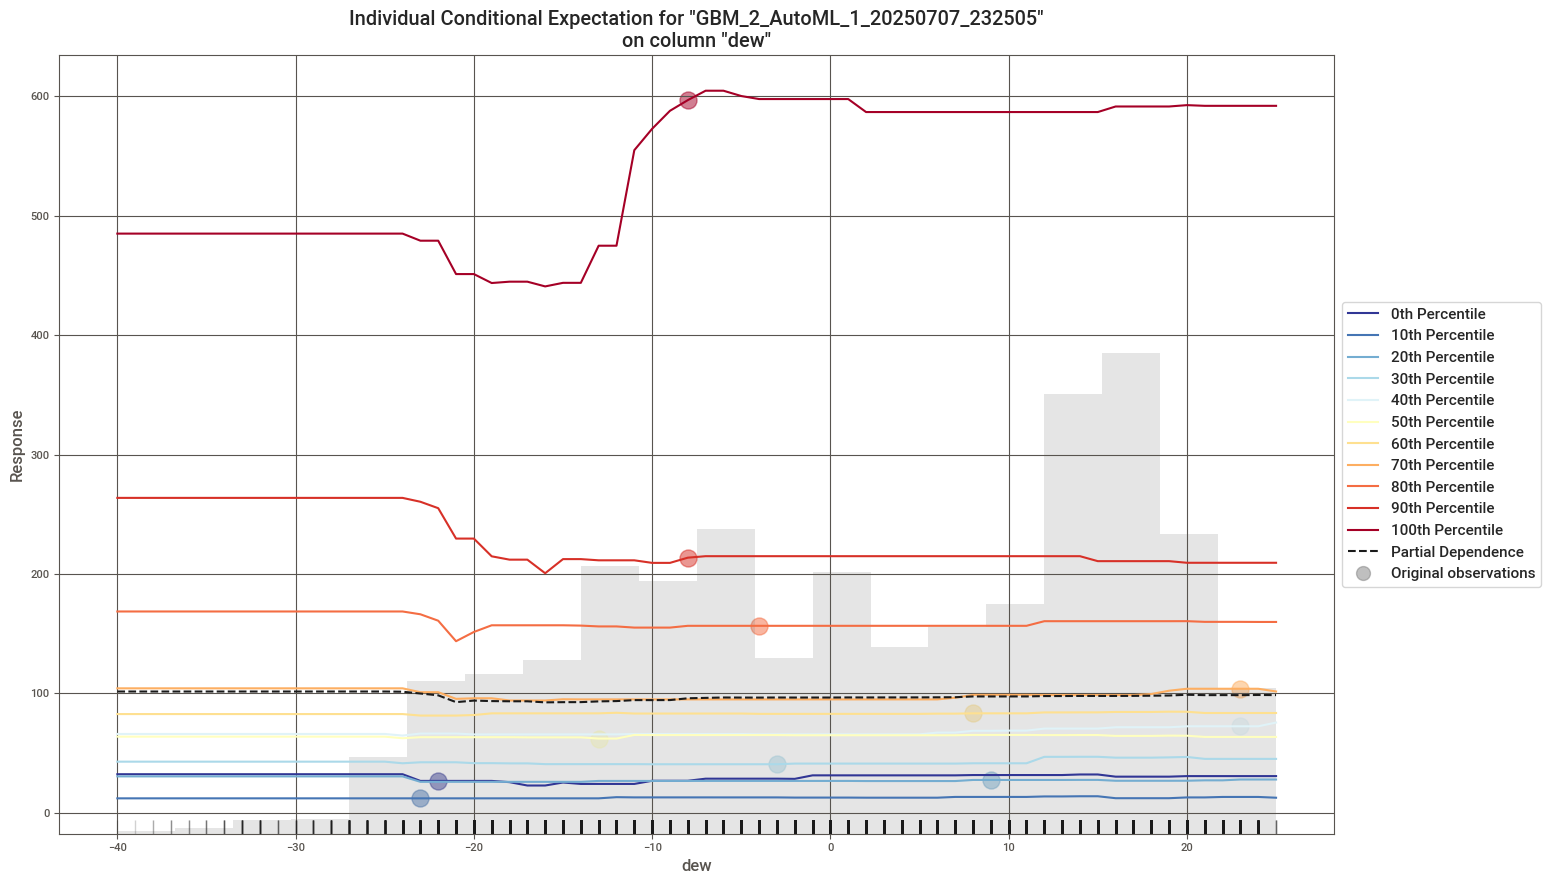

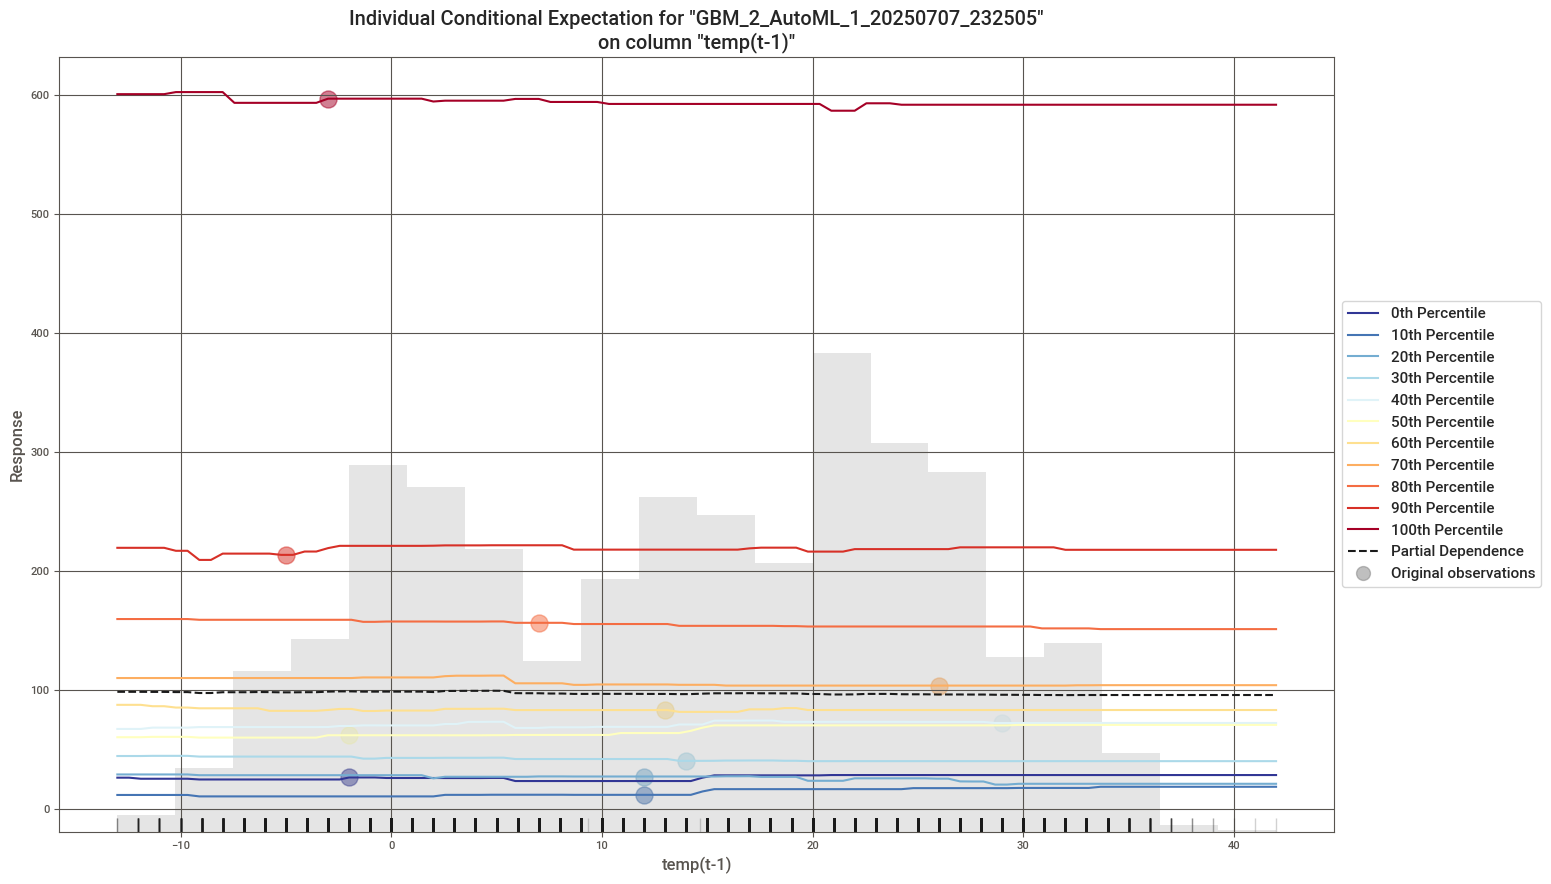

In [ ]:
# Explicación del modelo ganador
exm = aml.leader.explain(hf_test)

#como se puede explicar porque este es el modelo bueno-- como tener una mejor expicabilidad del modelo en si
#shap value -- valor de magnitud de cada una de las variables... inidicando la direccion del impacto sobvre la prediccion del modelo.

#seria una especie de grafico de feature importance pero con direccion...
#19.12  -- ver que significa lo negativo --  (pasado?)
#

[Interpretación de los Gráficos](https://www.analyticsvidhya.com/blog/2021/02/unboxing-h2o-automl-models/)

In [ ]:
# Cálculo del R2
slope, intercept, r_value, p_value, std_err = stats.linregress(x=df_results['predictions'],y=df_results['ground_truth'])
print('R2 = ',r_value*r_value)

R2 =  0.9375992780740705


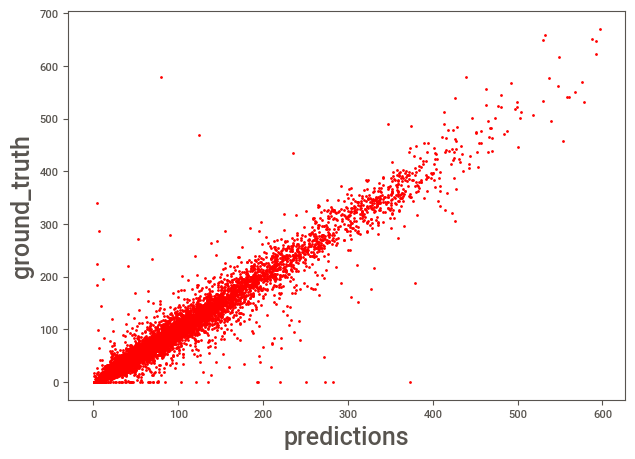

In [ ]:
# Gráfico de dispersión de las predciones y los valores reales
plt.scatter(x=df_results['predictions'],y=df_results['ground_truth'],s=1,c='red')
plt.xlabel('predictions',fontsize=18)
plt.ylabel('ground_truth',fontsize=18)
plt.show()

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


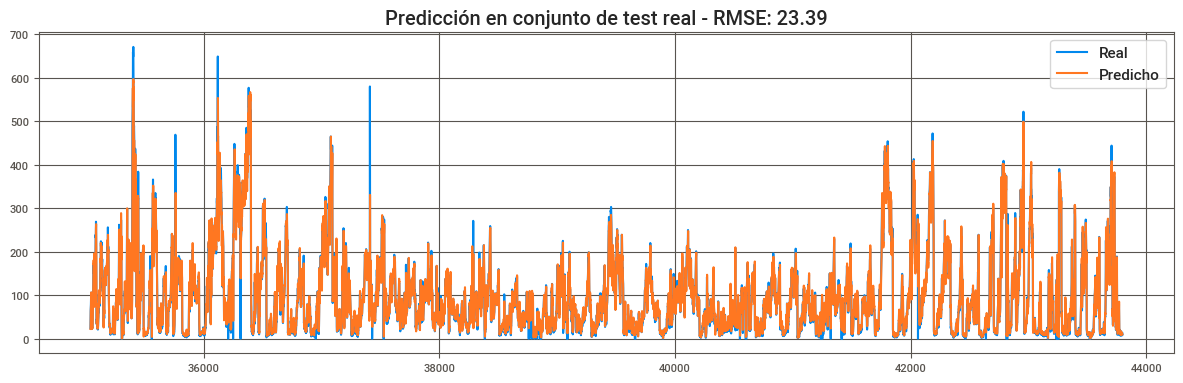

In [ ]:
# -----------------------------
# 6. Gráfico de predicciones
# -----------------------------
preds = aml.leader.predict(hf_test).as_data_frame()
actuals = df_test['pollution(t+1)'].values
ds_index = df_test.index

plt.figure(figsize=(12, 4))
plt.plot(ds_index, actuals, label="Real")
plt.plot(ds_index, preds["predict"], label="Predicho")
plt.legend()
plt.title(f"Predicción en conjunto de test real - RMSE: {perf.rmse():.2f}")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Gráfico de las predicciones junto con los valores reales
#plt.plot(df_results['ground_truth'])
#plt.plot(df_results['predictions'])
#plt.ylabel('pollution',fontsize=18)
#plt.legend(['ground_truth','prediction'])
#plt.show()

En este caso usamos la librería H2O. Existen otras librerías de AutoML ([ver artículo para más detalle](https://www.linkedin.com/pulse/top-10-automated-machine-learningauto-ml-tools-used-2020-2021-sahu/?trackingId=wwK1%2FFnjSkSqy%2BDWuM0Q%2Bg%3D%3D)), como así también liberías de AutoML específicas para Series de tiempo como [AutoTS](https://winedarksea.github.io/AutoTS/build/html/index.html).

### otra vuelta...

In [ ]:
url = 'https://raw.githubusercontent.com/braiandrago/AST/main/pollution.csv'
df = pd.read_csv(url, index_col=0, parse_dates=True)

Transformar a formato supervisado

In [ ]:
df_processed = time_series_to_supervised(df, n_lag=1, n_fut=1, selLag=None, selFut=['pollution'], dropnan=True)
df_processed = df_processed.rename(columns={"pollution(t+1)": "target"})

In [ ]:
target = "target"
features = [col for col in df_processed.columns if col != target]

In [ ]:
# -----------------------------
# Separar en train, val, test
# -----------------------------
n_total = len(df_processed)
n_test = 30
n_val = 30

df_train = df_processed.iloc[:n_total - n_val - n_test]
df_val = df_processed.iloc[n_total - n_val - n_test: n_total - n_test]
df_test = df_processed.iloc[n_total - n_test:]

Entrenar AutoML con validación temporal

In [ ]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,18 mins 23 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,3 months and 10 days
H2O_cluster_name:,H2O_from_python_unknownUser_71hfe8
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,2.987 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
hf_train = h2o.H2OFrame(df_train)
hf_val = h2o.H2OFrame(df_val)
hf_test = h2o.H2OFrame(df_test)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
aml = H2OAutoML(max_runtime_secs=120, nfolds=0, seed=42, verbosity="info", exclude_algos=['StackedEnsemble'])
aml.train(x=features, y=target, training_frame=hf_train, validation_frame=hf_val) # <------

AutoML progress: |
23:38:50.65: Project: AutoML_2_20250707_233850
23:38:50.65: Cross-validation disabled by user: no fold column nor nfolds > 1.
23:38:50.65: Setting stopping tolerance adaptively based on the training frame: 0.004781570240514433
23:38:50.65: Build control seed: 42
23:38:50.65: training frame: Frame key: AutoML_2_20250707_233850_training_Key_Frame__upload_a3d0c61f6fde762c45927eba2521422e.hex    cols: 17    rows: 43738  chunks: 1    size: 1158304  checksum: 395779241380555350
23:38:50.65: validation frame: Frame key: Key_Frame__upload_a14edef7380b564928f9af6507f748e2.hex    cols: 17    rows: 30  chunks: 1    size: 3166  checksum: -2583114975449478406
23:38:50.65: leaderboard frame: Frame key: Key_Frame__upload_a14edef7380b564928f9af6507f748e2.hex    cols: 17    rows: 30  chunks: 1    size: 3166  checksum: -2583114975449478406
23:38:50.65: blending frame: NULL
23:38:50.65: response column: target
23:38:50.65: fold column: null
23:38:50.65: weights column: null
23:38:50.66

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_grid_1_AutoML_2_20250707_233850_model_1


Model Summary: 
    number_of_trees
--  -----------------
    35

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 51.75229817555203
RMSE: 7.193907017438579
MAE: 5.000033290632016
RMSLE: NaN
Mean Residual Deviance: 51.75229817555203

ModelMetricsRegression: xgboost
** Reported on validation data. **

MSE: 904.1929044714841
RMSE: 30.06980053927003
MAE: 18.153419717152914
RMSLE: 0.4431309057787082
Mean Residual Deviance: 904.1929044714841

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance    validation_rmse    validation_mae    validation_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------  -----------------  ----------------  ---------------------
    2025-07-07 23:40:04  0.044 sec   0                  131.431          93.6337         17274                80.1602            63.3333           6425.65
    2025-07-07 23:40:05  0.478 sec   5                  27.1681          18.1198         738.106              30.8289            20.2969           950.421
    2025-07-07 23:40:05  1.089 sec   10                 13.3982          8.86328         179.513              29.709             17.8327           882.626
    2025-07-07 23:40:06  1.976 sec   15                 10.323           7.01983         106.564              30.101             17.8364           906.071
    2025-07-07 23:40:07  3.009 sec   20                 9.0457           6.19016         81.8246              30.1218            18.16             907.323
    2025-07-07 23:40:11  7.287 sec   25                 8.19716          5.66755         67.1934              30.1564            18.0971           909.41
    2025-07-07 23:40:14  10.377 sec  30                 7.72613          5.357           59.6931              29.9863            18.0758           899.178
    2025-07-07 23:40:16  11.515 sec  35                 7.19391          5.00003         51.7523              30.0698            18.1534           904.193

Variable Importances: 
variable         relative_importance    scaled_importance       percentage
---------------  ---------------------  ----------------------  ----------------------
pollution        615315968.0            1.0                     0.8521460247257522
pollution(t-1)   58459276.0             0.09500692171213083     0.08095977065842304
dew(t-1)         6787928.0              0.011031613598560147    0.00940054567432358
wnd_spd          6727920.5              0.010934090532167044    0.00931744178097763
temp(t-1)        6545032.5              0.010636864375994872    0.009064161693550997
dew              5059772.0              0.008223046797316334    0.007007236639466942
press            3761710.5              0.006113461531360746    0.0052095619412628694
press(t-1)       3743042.25             0.006083122240702195    0.005183708435335186
wnd_spd(t-1)     3473519.5              0.005645098909573561    0.0048104485949767885
temp             2799898.5              0.004550342662324668    0.0038775564108399613
---              ---                    ---                     ---
wnd_dir.NE       1050853.125            0.0017078268396246137   0.0014553178523060593
wnd_dir.cv       1041142.8125           0.0016920458214079697   0.0014418701203666214
wnd_dir(t-1).NW  1001933.9375           0.0016283242912688396   0.0013875700717691196
rain             879538.75              0.0014294099222856508   0.0012180659829792637
wnd_dir(t-1).NE  758347.5               0.0012324521700044684   0.0010502292173339347
wnd_dir(t-1).cv  737758.75              0.0011989917186742015   0.0010217160267473183
wnd_dir.NW       659084.9375            0.0010711325104113014   0.0009127613107015059
rain(t-1)        264576.75              0.0004299851844572966   0.0003664101656262546
snow             95325.4921875       

In [ ]:
# -----------------------------
# Evaluación en test final
# -----------------------------
perf = aml.leader.model_performance(hf_test)
print("RMSE final en test real:", perf.rmse())

RMSE final en test real: 11.391968234175804


In [ ]:
perf

ModelMetricsRegression: xgboost
** Reported on test data. **

MSE: 129.7769402484706
RMSE: 11.391968234175804
MAE: 6.201317262649536
RMSLE: 0.518613841292465
Mean Residual Deviance: 129.7769402484706

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


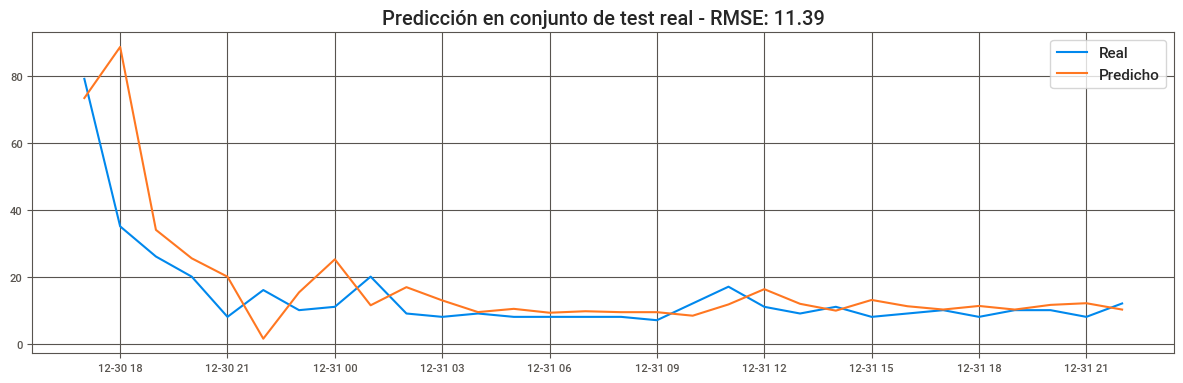

In [ ]:
# -----------------------------
# Gráfico de predicciones
# -----------------------------
preds = aml.leader.predict(hf_test).as_data_frame()
actuals = df_test[target].values
ds_index = df_test.index

plt.figure(figsize=(12, 4))
plt.plot(ds_index, actuals, label="Real")
plt.plot(ds_index, preds["predict"], label="Predicho")
plt.legend()
plt.title(f"Predicción en conjunto de test real - RMSE: {perf.rmse():.2f}")
plt.grid(True)
plt.tight_layout()
plt.show()